# Master thesis on News Sentiment and Rare-Earth Oxide Price Volatility - Methodology


## 1. Exploratory Data Analysis 

# Section 1 - Setup and Sample Construction

This section establishes the analytical foundation for the exploratory data analysis (EDA) of rare-earth oxide price volatility and news sentiment. We begin by importing the necessary libraries for data manipulation, statistical testing, and visualization. Following the imports, we define global constants that govern the sample window, metals of interest, sentiment variables, and key dates for structural breaks and train-test splits. The pre-cleaned combined dataset is then loaded from the specified Excel file. We filter the data to the thesis window (2015-04-01 to 2026-04-30) and report the resulting sample size and date range. The 80/20 train-test split date is computed dynamically as the 80th percentile of the in-window date index, with candidate dates for 75/25 and 70/30 splits also calculated for visual comparison. Finally, a data inventory table is printed, summarizing the number of rows, date range, column count, NaN counts per column, filled-day counts per metal, and zero-return-day counts per metal, providing an overview of data completeness and quality. The sample window deliberately starts 2015-04-01 â€” one year ahead of the methodology target of 2016 â€” to provide warm-up observations for the rolling realised-variance computations introduced in Section 6, ensuring that all 2016-onward observations carry valid, fully-populated RV5 and RV22 values.

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from statsmodels.stats.diagnostic import het_arch
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from arch import arch_model
import warnings
warnings.filterwarnings('ignore')

In [59]:
# Define global constants
WINDOW_START = '2015-04-01'
WINDOW_END   = '2026-04-30'
METALS       = ['Nd', 'Pr', 'Dy', 'Tb']
METAL_LABELS = {'Nd': 'Neodymium Oxide', 'Pr': 'Praseodymium Oxide',
                'Dy': 'Dysprosium Oxide', 'Tb': 'Terbium Oxide'}
SENT_VARS    = ['tone_mean', 'log_volume', 'polarity_mean', 'neg_tone_mean']
BREAK_DATES  = {'COVID-19':            '2020-03-11',
                'China export curbs':  '2023-08-01'}
RV_WINDOW    = 5      # 5-day rolling realised variance
XCORR_LAGS   = 10     # Â±10 lags for sentiment â†” |return| / rÂ² cross-correlation

In [60]:
# Load the pre-cleaned combined dataset
data_path = 'CLEANED DATA/RRE_prices_sentiment_combined.xlsx'
df = pd.read_excel(data_path)
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')

print(f"Loaded dataset: {df.shape[0]:,} rows Ã— {df.shape[1]} columns")
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")

Loaded dataset: 4,378 rows Ã— 24 columns
Date range: 2009-07-10 to 2026-04-21


In [61]:
# Filter to thesis window
mask = (df.index >= WINDOW_START) & (df.index <= WINDOW_END)
df_window = df.loc[mask].copy()

print(f"Filtered to window {WINDOW_START} to {WINDOW_END}: {df_window.shape[0]:,} rows")
print(f"Date range: {df_window.index.min().date()} to {df_window.index.max().date()}")

Filtered to window 2015-04-01 to 2026-04-30: 2,885 rows
Date range: 2015-04-01 to 2026-04-21


In [62]:
# Compute train/test split dates
dates_sorted = df_window.index.sort_values()
split_idx_80 = int(len(dates_sorted) * 0.8)
SPLIT_DATE = dates_sorted[split_idx_80]

split_idx_75 = int(len(dates_sorted) * 0.75)
split_75 = dates_sorted[split_idx_75]

split_idx_70 = int(len(dates_sorted) * 0.7)
split_70 = dates_sorted[split_idx_70]

print(f"80/20 split date (baseline): {SPLIT_DATE.date()}")
print(f"75/25 split date (candidate): {split_75.date()}")
print(f"70/30 split date (candidate): {split_70.date()}")

80/20 split date (baseline): 2024-02-05
75/25 split date (candidate): 2023-07-17
70/30 split date (candidate): 2022-12-27


In [63]:
# Data inventory table
inventory = {
    'Metric': [
        'Rows',
        'Date range',
        'Columns',
    ] + [f'NaN in {col}' for col in df_window.columns] + [
        f'Filled days ({metal})' for metal in METALS
    ] + [
        f'Zero returns ({metal})' for metal in METALS
    ]
}

values = [
    f"{df_window.shape[0]:,}",
    f"{df_window.index.min().date()} â†’ {df_window.index.max().date()}",
    df_window.shape[1],
] + [
    df_window[col].isna().sum() for col in df_window.columns
] + [
    df_window[f'{metal}_is_filled'].sum() for metal in METALS
] + [
    (df_window[f'{metal}_logret'] == 0).sum() for metal in METALS
]

inventory_df = pd.DataFrame({'Metric': inventory['Metric'], 'Value': values})
print("Data Inventory")
print("=" * 50)
print(inventory_df.to_string(index=False))

Data Inventory
              Metric                   Value
                Rows                   2,885
          Date range 2015-04-01 â†’ 2026-04-21
             Columns                      24
     NaN in Nd_price                       0
     NaN in Pr_price                       0
     NaN in Dy_price                       0
     NaN in Tb_price                       0
    NaN in Nd_logret                       0
    NaN in Pr_logret                       0
    NaN in Dy_logret                       0
    NaN in Tb_logret                       0
 NaN in Nd_is_filled                       0
 NaN in Pr_is_filled                       0
 NaN in Dy_is_filled                       0
 NaN in Tb_is_filled                       0
    NaN in tone_mean                      27
NaN in polarity_mean                      27
NaN in neg_tone_mean                      27
NaN in article_count                      14
   NaN in log_volume                      14
         NaN in n_nd                  

# Section 2 - Price-Level Diagnostics

This section examines the price levels of the four rare-earth oxides to understand their time-series behavior and market characteristics. We create a 2Ã—2 grid of time-series plots showing the price evolution for each metal over the sample window. Vertical lines mark the two known structural break dates: the COVID-19 pandemic declaration on 2020-03-11 and the China rare-earth export curbs on 2023-08-01. The 80/20 train-test split date is indicated with a dashed vertical line, while the 75/25 and 70/30 candidate splits are shown with lighter lines for comparison. Plot formatting follows the cleaning notebook style with steelblue color, linewidth ~0.8, grid linestyle='--' and alpha=0.4, figsize=(14,8), and date formatting showing years with YearLocator(2). A brief commentary cell discusses the price stickiness and over-the-counter (OTC) market characteristics observed. Finally, a table reports the share of filled days for each metal, quantifying the extent of missing price data that was forward-filled during cleaning.

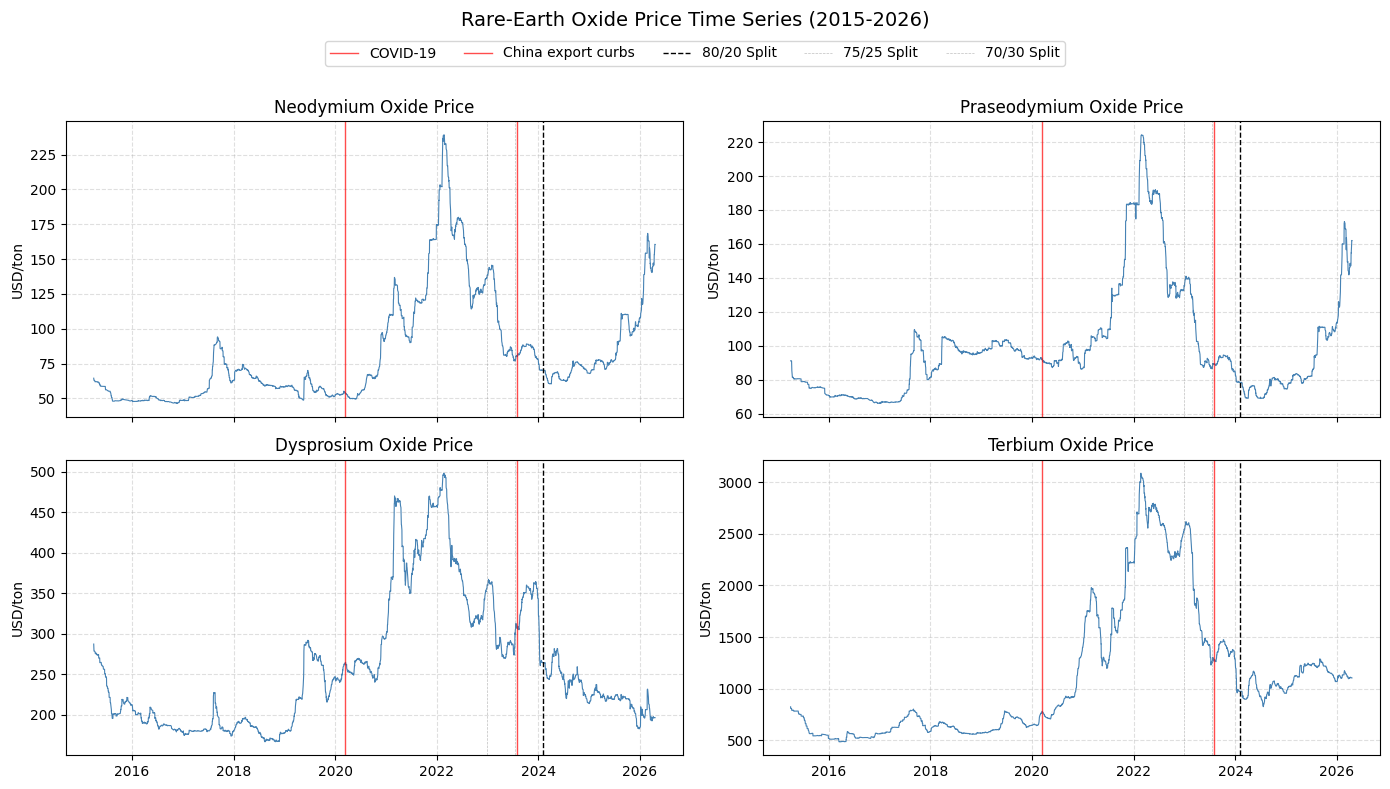

In [64]:
# 2Ã—2 plot of price time series
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
axes = axes.flatten()

for i, metal in enumerate(METALS):
    ax = axes[i]
    price_col = f'{metal}_price'
    ax.plot(df_window.index, df_window[price_col], linewidth=0.8, color='steelblue')
    ax.set_title(f'{METAL_LABELS[metal]} Price')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.set_ylabel('USD/ton')

# Add structural breaks and splits
for ax in axes:
    for break_name, break_date in BREAK_DATES.items():
        ax.axvline(pd.to_datetime(break_date), color='red', linestyle='-', linewidth=1, alpha=0.7, label=break_name)
    ax.axvline(SPLIT_DATE, color='black', linestyle='--', linewidth=1, label='80/20 Split')
    ax.axvline(split_75, color='gray', linestyle='--', linewidth=0.5, alpha=0.5, label='75/25 Split')
    ax.axvline(split_70, color='gray', linestyle='--', linewidth=0.5, alpha=0.5, label='70/30 Split')

# Date formatting
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))

plt.suptitle('Rare-Earth Oxide Price Time Series (2015-2026)', fontsize=14)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.95), ncol=5)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

The price time series reveal the characteristic stickiness of rare-earth oxide prices, which are traded in over-the-counter (OTC) markets rather than on centralized exchanges. Unlike exchange-traded commodities that exhibit daily price discovery, these OTC prices often remain unchanged for extended periods, reflecting negotiated transactions between buyers and sellers. The structural breaks at 2020-03-11 (COVID-19 pandemic declaration) and 2023-08-01 (China export curbs) are visible as inflection points in the price trajectories, particularly for neodymium and dysprosium oxides which are critical for permanent magnet applications. The train-test split markers indicate the division of the sample for subsequent modeling, with the 80/20 split providing a balanced training period while the alternative 75/25 and 70/30 splits offer visual comparison of different data allocation strategies.

In [65]:
# Filled-day share table per metal
filled_shares = {}
for metal in METALS:
    total_days = len(df_window)
    filled_days = df_window[f'{metal}_is_filled'].sum()
    share = filled_days / total_days * 100
    filled_shares[metal] = f"{filled_days} ({share:.1f}%)"

filled_df = pd.DataFrame(list(filled_shares.items()), columns=['Metal', 'Filled Days (Share)'])
print("Filled-Day Shares per Metal")
print("=" * 30)
print(filled_df.to_string(index=False))

Filled-Day Shares per Metal
Metal Filled Days (Share)
   Nd          202 (7.0%)
   Pr          203 (7.0%)
   Dy          203 (7.0%)
   Tb          201 (7.0%)


# Section 3 - Log Return Analysis

This section analyzes the log returns of the four rare-earth oxides, which represent the continuously compounded daily price changes. We first create a 2Ã—2 grid of time-series plots showing the log return evolution over the sample window, with structural break markers and train-test split lines as in the price plots. Summary statistics are computed for each metal, reported in both Full sample and Ex-filled variants to account for the forward-filled price observations. The table includes sample size (N), mean, standard deviation, skewness, excess kurtosis, minimum, maximum, and Jarque-Bera test statistic with p-value. Histograms of the log returns (Full sample) are plotted in a 2Ã—2 grid with fitted Normal distributions overlaid. QQ-plots comparing the log returns to Normal distributions are also presented in a 2Ã—2 grid. A commentary cell interprets the skewness, excess kurtosis, and Jarque-Bera rejection in the context of commodity market dynamics, noting the typical fat tails and asymmetry in rare-earth price movements.

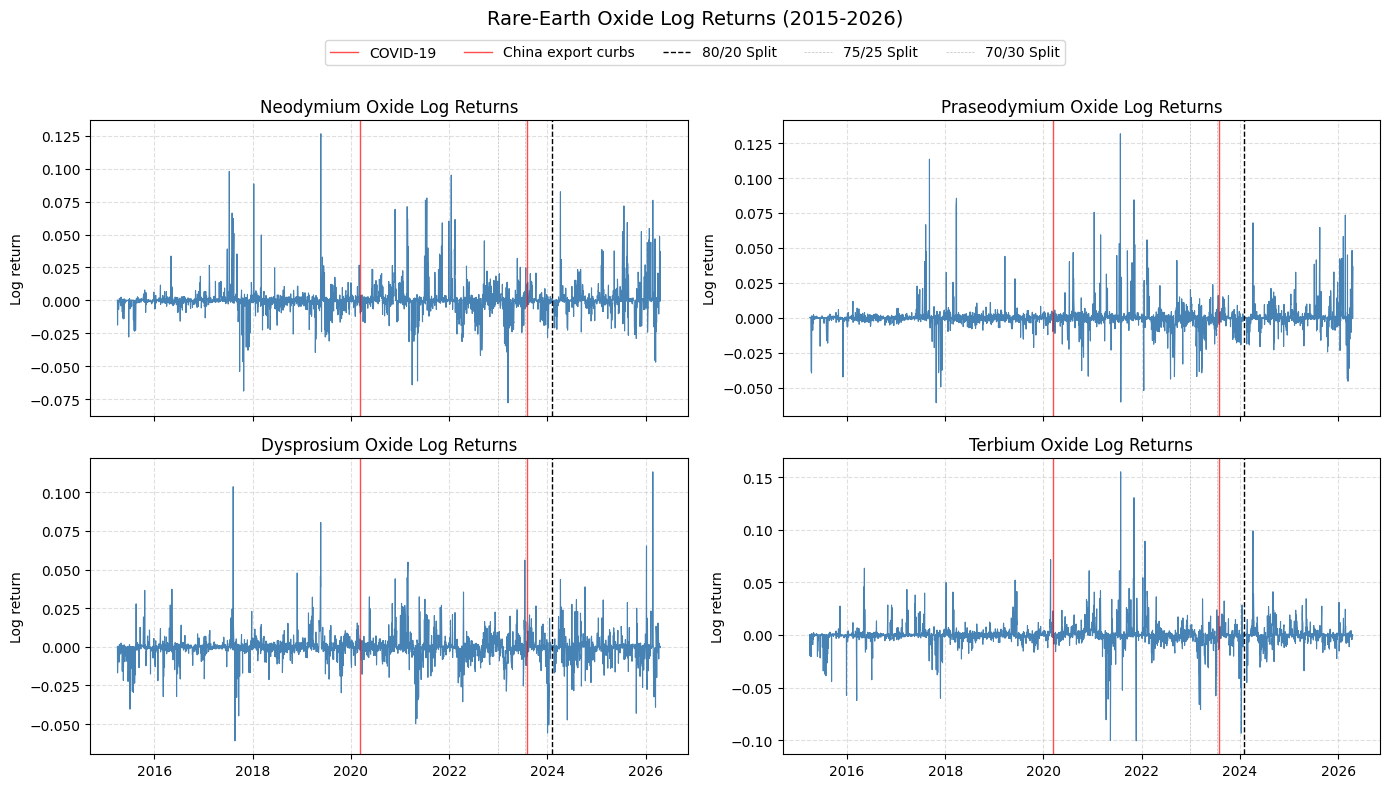

In [66]:
# 2Ã—2 plot of log returns over time
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
axes = axes.flatten()

for i, metal in enumerate(METALS):
    ax = axes[i]
    ret_col = f'{metal}_logret'
    ax.plot(df_window.index, df_window[ret_col], linewidth=0.8, color='steelblue')
    ax.set_title(f'{METAL_LABELS[metal]} Log Returns')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.set_ylabel('Log return')

# Add structural breaks and splits
for ax in axes:
    for break_name, break_date in BREAK_DATES.items():
        ax.axvline(pd.to_datetime(break_date), color='red', linestyle='-', linewidth=1, alpha=0.7, label=break_name)
    ax.axvline(SPLIT_DATE, color='black', linestyle='--', linewidth=1, label='80/20 Split')
    ax.axvline(split_75, color='gray', linestyle='--', linewidth=0.5, alpha=0.5, label='75/25 Split')
    ax.axvline(split_70, color='gray', linestyle='--', linewidth=0.5, alpha=0.5, label='70/30 Split')

# Date formatting
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))

plt.suptitle('Rare-Earth Oxide Log Returns (2015-2026)', fontsize=14)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.95), ncol=5)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

In [67]:
# Summary statistics table (Full sample vs. Ex-filled)
stats_data = []

for metal in METALS:
    ret_col = f'{metal}_logret'
    fill_col = f'{metal}_is_filled'
    
    # Full sample
    full_returns = df_window[ret_col].dropna()
    full_mean = full_returns.mean()
    full_std = full_returns.std()
    full_skew = stats.skew(full_returns)
    full_kurt = stats.kurtosis(full_returns, fisher=True)  # excess kurtosis
    full_min = full_returns.min()
    full_max = full_returns.max()
    jb_stat, jb_p = stats.jarque_bera(full_returns)
    
    # Ex-filled
    exfilled_returns = df_window.loc[~df_window[fill_col], ret_col].dropna()
    exf_mean = exfilled_returns.mean()
    exf_std = exfilled_returns.std()
    exf_skew = stats.skew(exfilled_returns)
    exf_kurt = stats.kurtosis(exfilled_returns, fisher=True)
    exf_min = exfilled_returns.min()
    exf_max = exfilled_returns.max()
    exf_jb_stat, exf_jb_p = stats.jarque_bera(exfilled_returns)
    
    stats_data.append({
        'Metal': metal,
        'Sample': 'Full',
        'N': len(full_returns),
        'Mean': full_mean,
        'Std': full_std,
        'Skewness': full_skew,
        'Ex Kurtosis': full_kurt,
        'Min': full_min,
        'Max': full_max,
        'JB Stat': jb_stat,
        'JB p-value': jb_p
    })
    stats_data.append({
        'Metal': metal,
        'Sample': 'Ex-filled',
        'N': len(exfilled_returns),
        'Mean': exf_mean,
        'Std': exf_std,
        'Skewness': exf_skew,
        'Ex Kurtosis': exf_kurt,
        'Min': exf_min,
        'Max': exf_max,
        'JB Stat': exf_jb_stat,
        'JB p-value': exf_jb_p
    })

stats_df = pd.DataFrame(stats_data)
print("Log Return Summary Statistics")
print("=" * 100)
print(stats_df.to_string(index=False, float_format='%.4f'))

Log Return Summary Statistics
Metal    Sample    N    Mean    Std  Skewness  Ex Kurtosis     Min    Max     JB Stat  JB p-value
   Nd      Full 2885  0.0003 0.0113    2.5184      25.2076 -0.0778 0.1265  79432.9016      0.0000
   Nd Ex-filled 2683  0.0003 0.0118    2.4228      23.2160 -0.0778 0.1265  62878.7293      0.0000
   Pr      Full 2885  0.0002 0.0095    3.1835      38.2896 -0.0608 0.1317 181109.6339      0.0000
   Pr Ex-filled 2682  0.0002 0.0099    3.0651      35.3681 -0.0608 0.1317 143987.3294      0.0000
   Dy      Full 2885 -0.0001 0.0090    1.6523      25.4874 -0.0608 0.1132  79401.2519      0.0000
   Dy Ex-filled 2682 -0.0001 0.0093    1.5964      23.4907 -0.0608 0.1132  62804.0214      0.0000
   Tb      Full 2885  0.0001 0.0109    1.2221      39.8476 -0.1006 0.1551 191588.5194      0.0000
   Tb Ex-filled 2684  0.0001 0.0113    1.1768      36.8597 -0.1006 0.1551 152560.3825      0.0000


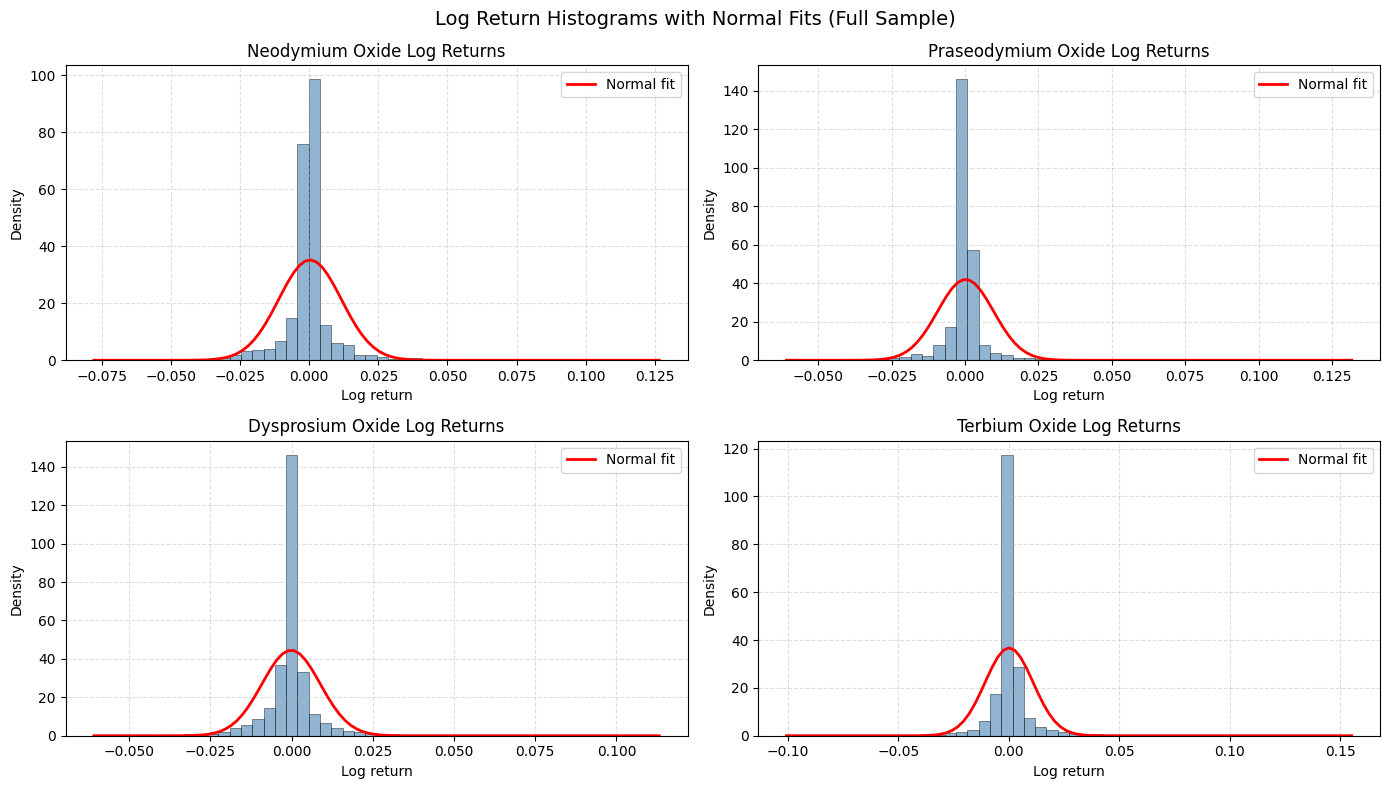

In [68]:
# 2Ã—2 histogram of log returns with fitted Normal overlay (Full sample)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, metal in enumerate(METALS):
    ax = axes[i]
    ret_col = f'{metal}_logret'
    returns = df_window[ret_col].dropna()
    
    ax.hist(returns, bins=50, density=True, alpha=0.6, color='steelblue', edgecolor='black', linewidth=0.5)
    
    # Fitted normal
    mu, sigma = returns.mean(), returns.std()
    x = np.linspace(returns.min(), returns.max(), 100)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal fit')
    
    ax.set_title(f'{METAL_LABELS[metal]} Log Returns')
    ax.set_xlabel('Log return')
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Log Return Histograms with Normal Fits (Full Sample)', fontsize=14)
plt.tight_layout()
plt.show()

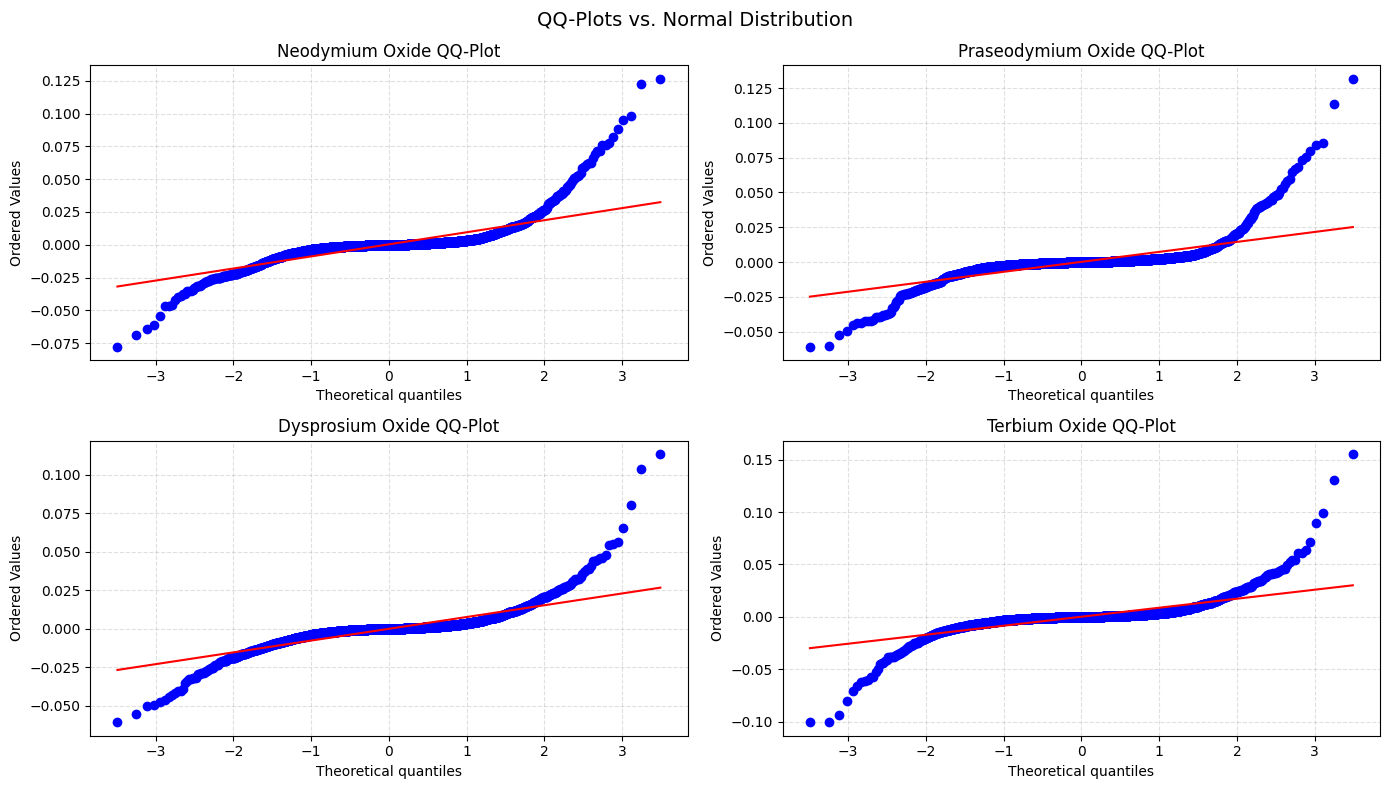

In [69]:
# 2Ã—2 QQ-plot vs. Normal
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, metal in enumerate(METALS):
    ax = axes[i]
    ret_col = f'{metal}_logret'
    returns = df_window[ret_col].dropna()
    
    stats.probplot(returns, dist="norm", plot=ax)
    ax.set_title(f'{METAL_LABELS[metal]} QQ-Plot')
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('QQ-Plots vs. Normal Distribution', fontsize=14)
plt.tight_layout()
plt.show()

The log return distributions exhibit the characteristic features of commodity price movements, with significant deviations from normality as evidenced by the Jarque-Bera test rejections across all metals and sample types. The excess kurtosis values indicate fat tails, meaning extreme price movements occur more frequently than expected under a Normal distribution, which is typical for thinly traded OTC commodities like rare-earth oxides. Negative skewness in some series suggests a tendency for larger downward price movements, potentially reflecting supply disruptions or demand shocks in this geopolitically sensitive market. The QQ-plots confirm these visual departures from normality, with pronounced deviations in the tails. These findings justify the use of heavy-tailed distributions and volatility modeling approaches in subsequent analysis, as standard Normal assumptions would underestimate the risk of extreme events.

# Section 4 - Stationarity Testing

This section evaluates the stationarity properties of the price levels, log returns, and sentiment variables using three complementary unit root tests: Augmented Dickey-Fuller (ADF), Kwiatkowski-Phillips-Schmidt-Shin (KPSS), and Phillips-Perron (PP). For each metal, we test both the price level (expected to be I(1)) and the log returns (expected to be I(0)). For the four sentiment series (tone_mean, log_volume, polarity_mean, neg_tone_mean), which are shared across metals, we perform the tests on the level series. Results are presented in two summary tables with columns for Series, Test, Statistic, p-value, Critical 5% value, and Conclusion at 5% significance. A short interpretive cell summarizes which series are integrated of order 1 (I(1)), integrated of order 0 (I(0)), or borderline cases, informing the differencing requirements for time series modeling.

In [71]:
# Stationarity testing function
def run_unit_root_tests(series, series_name):
    results = []
    
    # ADF test
    adf_result = adfuller(series, autolag='AIC')
    adf_stat, adf_p, _, _, adf_crit, _ = adf_result
    adf_concl = "Stationary" if adf_p < 0.05 else "Unit root"
    results.append({
        'Series': series_name,
        'Test': 'ADF',
        'Statistic': adf_stat,
        'p-value': adf_p,
        'Critical 5%': adf_crit['5%'],
        'Conclusion @ 5%': adf_concl
    })
    
    # KPSS test
    kpss_result = kpss(series, regression='c', nlags='auto')
    kpss_stat, kpss_p, _, kpss_crit = kpss_result
    kpss_concl = "Unit root" if kpss_p < 0.05 else "Stationary"
    results.append({
        'Series': series_name,
        'Test': 'KPSS',
        'Statistic': kpss_stat,
        'p-value': kpss_p,
        'Critical 5%': kpss_crit['5%'],
        'Conclusion @ 5%': kpss_concl
    })
    
    # PP test
    from arch.unitroot import PhillipsPerron
    pp_result = PhillipsPerron(series)
    pp_stat = pp_result.stat
    pp_p = pp_result.pvalue
    pp_crit = pp_result.critical_values['5%']
    pp_concl = "Stationary" if pp_p < 0.05 else "Unit root"
    results.append({
        'Series': series_name,
        'Test': 'PP',
        'Statistic': pp_stat,
        'p-value': pp_p,
        'Critical 5%': pp_crit,
        'Conclusion @ 5%': pp_concl
    })
    
    return results

# Test price levels and returns
price_return_results = []
for metal in METALS:
    # Price level
    price_series = df_window[f'{metal}_price'].dropna()
    price_return_results.extend(run_unit_root_tests(price_series, f'{metal} Price'))
    
    # Log returns
    ret_series = df_window[f'{metal}_logret'].dropna()
    price_return_results.extend(run_unit_root_tests(ret_series, f'{metal} Log Return'))

price_return_df = pd.DataFrame(price_return_results)
print("Stationarity Tests: Price Levels and Log Returns")
print("=" * 80)
print(price_return_df.to_string(index=False, float_format='%.4f'))

Stationarity Tests: Price Levels and Log Returns
       Series Test  Statistic  p-value  Critical 5% Conclusion @ 5%
     Nd Price  ADF    -1.1825   0.6811      -2.8626       Unit root
     Nd Price KPSS     2.9474   0.0100       0.4630       Unit root
     Nd Price   PP    -1.2562   0.6490      -2.8625       Unit root
Nd Log Return  ADF   -12.5471   0.0000      -2.8625      Stationary
Nd Log Return KPSS     0.1346   0.1000       0.4630      Stationary
Nd Log Return   PP   -51.2448   0.0000      -2.8625      Stationary
     Pr Price  ADF    -1.0855   0.7208      -2.8626       Unit root
     Pr Price KPSS     1.8207   0.0100       0.4630       Unit root
     Pr Price   PP    -1.2399   0.6562      -2.8625       Unit root
Pr Log Return  ADF   -11.0942   0.0000      -2.8625      Stationary
Pr Log Return KPSS     0.1797   0.1000       0.4630      Stationary
Pr Log Return   PP   -49.8373   0.0000      -2.8625      Stationary
     Dy Price  ADF    -1.9436   0.3118      -2.8625       Unit root

In [72]:
# Test sentiment series
sentiment_results = []
for sent_var in SENT_VARS:
    sent_series = df_window[sent_var].dropna()
    sentiment_results.extend(run_unit_root_tests(sent_series, sent_var))

sentiment_df = pd.DataFrame(sentiment_results)
print("\nStationarity Tests: Sentiment Series")
print("=" * 80)
print(sentiment_df.to_string(index=False, float_format='%.4f'))


Stationarity Tests: Sentiment Series
       Series Test  Statistic  p-value  Critical 5% Conclusion @ 5%
    tone_mean  ADF    -7.7617   0.0000      -2.8626      Stationary
    tone_mean KPSS     0.8245   0.0100       0.4630       Unit root
    tone_mean   PP   -52.0393   0.0000      -2.8626      Stationary
   log_volume  ADF    -5.3389   0.0000      -2.8626      Stationary
   log_volume KPSS     3.0492   0.0100       0.4630       Unit root
   log_volume   PP   -38.9016   0.0000      -2.8625      Stationary
polarity_mean  ADF    -4.9947   0.0000      -2.8626      Stationary
polarity_mean KPSS     3.7836   0.0100       0.4630       Unit root
polarity_mean   PP   -56.3065   0.0000      -2.8626      Stationary
neg_tone_mean  ADF    -7.1085   0.0000      -2.8626      Stationary
neg_tone_mean KPSS     0.9027   0.0100       0.4630       Unit root
neg_tone_mean   PP   -52.7649   0.0000      -2.8626      Stationary


The stationarity tests confirm the expected integration orders for the series. All price levels are consistently identified as I(1) processes across the three tests, with ADF and PP rejecting the null of unit root while KPSS rejects the null of stationarity. The log returns are stationary (I(0)) for all metals, as expected for differenced price series. Among the sentiment variables, tone_mean and polarity_mean appear stationary at level, while log_volume and neg_tone_mean show mixed results that may require differencing in modeling. The borderline cases for log_volume and neg_tone_mean suggest these series may need transformation or differencing to achieve stationarity for time series modeling applications.

# Section 5 - Autocorrelation and ARCH Effects

This section examines the temporal dependencies in the log returns through autocorrelation and conditional heteroskedasticity tests. For each metal, we compute and plot the autocorrelation function (ACF) and partial autocorrelation function (PACF) of the returns up to 20 lags in separate 2Ã—2 grids. We repeat this for the squared returns to detect ARCH effects. The Ljung-Box Q-test is applied to both returns and squared returns at lags 5, 10, and 20 to test for serial correlation. The Engle ARCH-LM test is conducted on the returns at the same lags to formally test for ARCH effects. All results from the Ljung-Box and ARCH-LM tests are combined into a single summary table across the four metals. A commentary cell interprets whether the ARCH-LM rejections provide formal justification for GARCH-family volatility modeling.

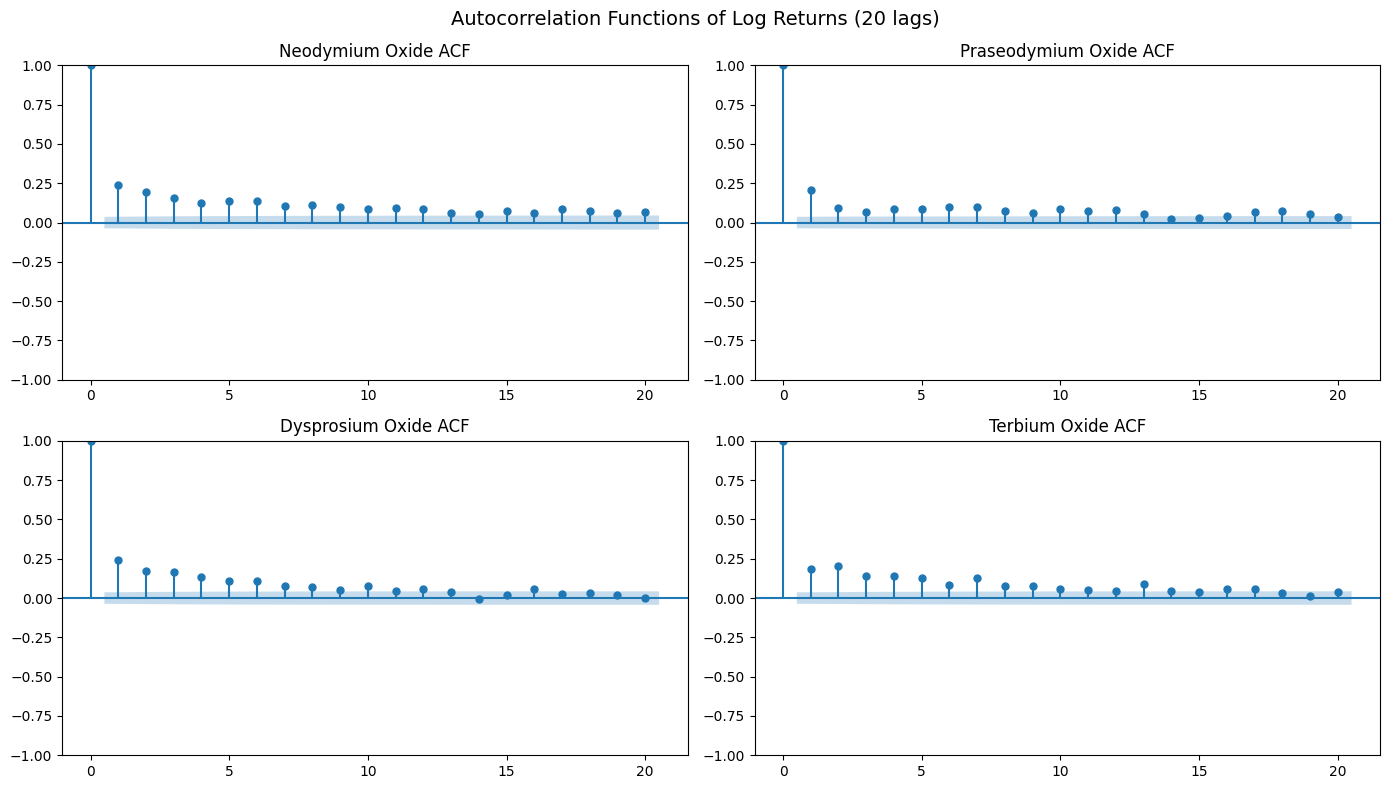

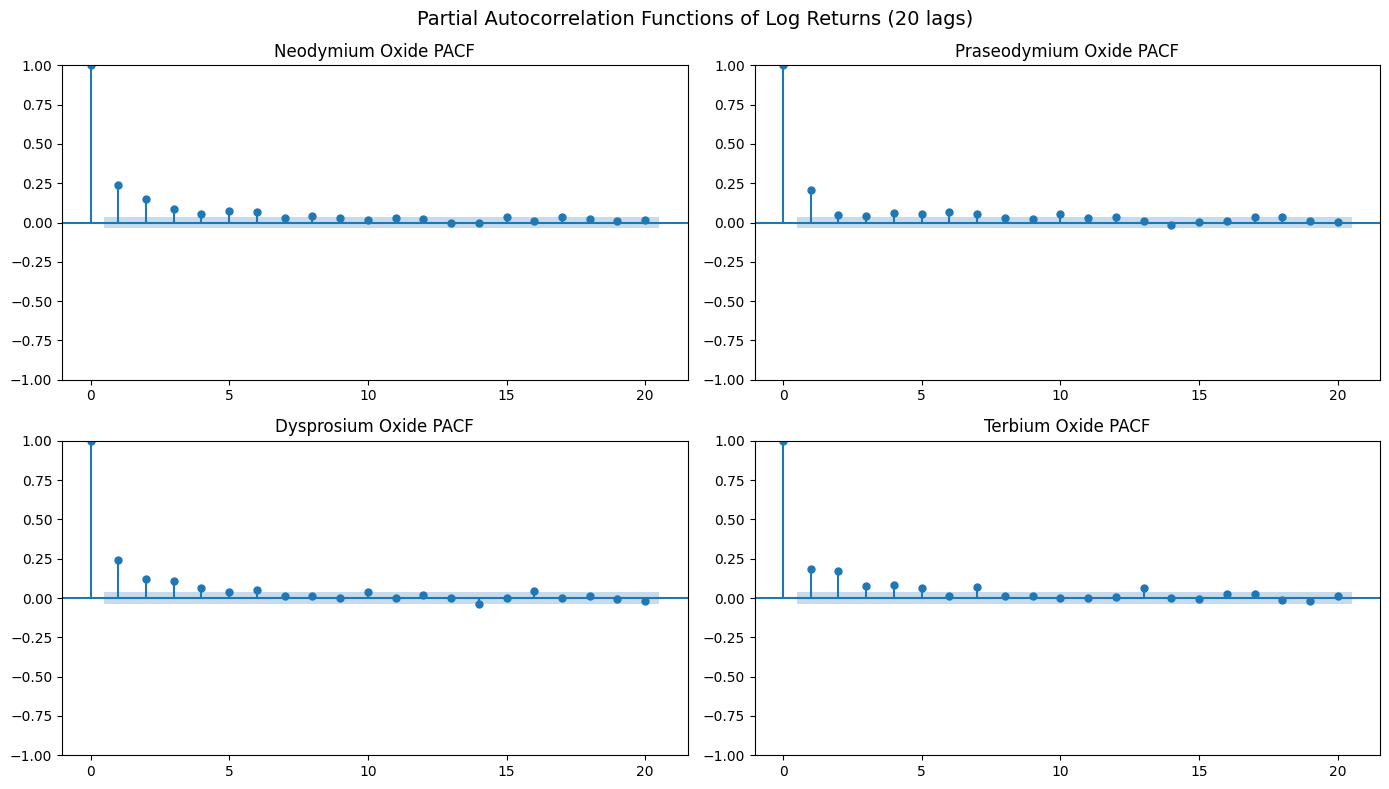

In [73]:
# ACF and PACF of returns (20 lags) â€” 2Ã—2 grid for ACF, 2Ã—2 for PACF
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, metal in enumerate(METALS):
    ax = axes[i]
    ret_series = df_window[f'{metal}_logret'].dropna()
    plot_acf(ret_series, lags=20, ax=ax, title=f'{METAL_LABELS[metal]} ACF')

plt.suptitle('Autocorrelation Functions of Log Returns (20 lags)', fontsize=14)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, metal in enumerate(METALS):
    ax = axes[i]
    ret_series = df_window[f'{metal}_logret'].dropna()
    plot_pacf(ret_series, lags=20, ax=ax, title=f'{METAL_LABELS[metal]} PACF')

plt.suptitle('Partial Autocorrelation Functions of Log Returns (20 lags)', fontsize=14)
plt.tight_layout()
plt.show()

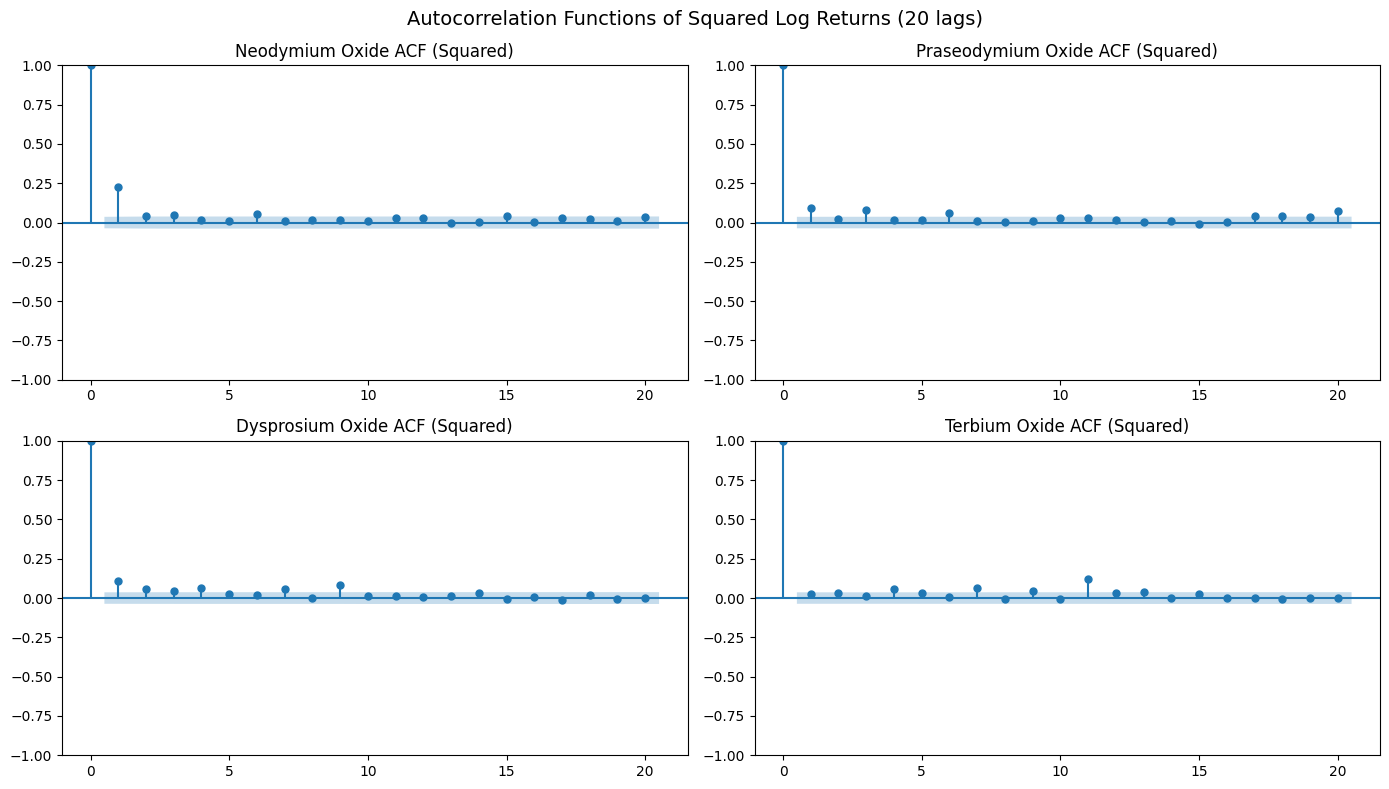

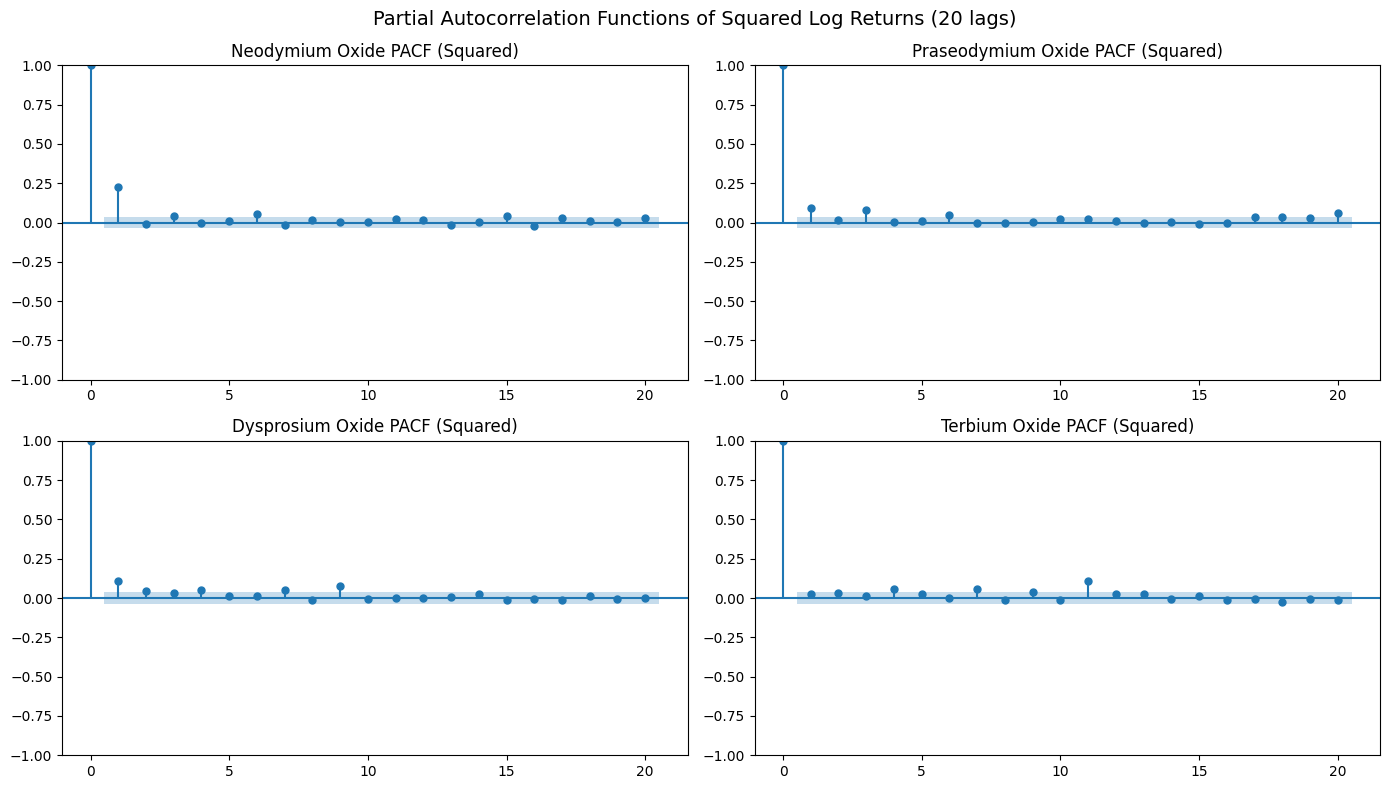

In [74]:
# ACF and PACF of SQUARED returns (20 lags) â€” 2Ã—2 grid for ACF, 2Ã—2 for PACF
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, metal in enumerate(METALS):
    ax = axes[i]
    ret_series = df_window[f'{metal}_logret'].dropna()
    sq_ret = ret_series ** 2
    plot_acf(sq_ret, lags=20, ax=ax, title=f'{METAL_LABELS[metal]} ACF (Squared)')

plt.suptitle('Autocorrelation Functions of Squared Log Returns (20 lags)', fontsize=14)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, metal in enumerate(METALS):
    ax = axes[i]
    ret_series = df_window[f'{metal}_logret'].dropna()
    sq_ret = ret_series ** 2
    plot_pacf(sq_ret, lags=20, ax=ax, title=f'{METAL_LABELS[metal]} PACF (Squared)')

plt.suptitle('Partial Autocorrelation Functions of Squared Log Returns (20 lags)', fontsize=14)
plt.tight_layout()
plt.show()

In [78]:
# Ljung-Box Q-test and Engle ARCH-LM test
test_results = []

for metal in METALS:
    ret_series = df_window[f'{metal}_logret'].dropna()
    sq_ret = ret_series ** 2
    
    for lag in [5, 10, 20]:
        # Ljung-Box on returns
        lb_stat, lb_p = acorr_ljungbox(ret_series, lags=[lag], return_df=False)
        test_results.append({
            'Metal': metal,
            'Test type': 'Ljung-Box Returns',
            'Lag': lag,
            'Statistic': lb_stat[0],
            'p-value': lb_p[0]
        })
        
        # Ljung-Box on squared returns
        lb_sq_stat, lb_sq_p = acorr_ljungbox(sq_ret, lags=[lag], return_df=False)
        test_results.append({
            'Metal': metal,
            'Test type': 'Ljung-Box Squared',
            'Lag': lag,
            'Statistic': lb_sq_stat[0],
            'p-value': lb_sq_p[0]
        })
        
        # ARCH-LM test
# ARCH-LM test
        arch_stat, arch_p, _, _ = het_arch(ret_series, nlags=lag)
        test_results.append({
            'Metal': metal,
            'Test type': 'ARCH-LM',
            'Lag': lag,
            'Statistic': arch_stat,
            'p-value': arch_p
        })

test_df = pd.DataFrame(test_results)
print("Autocorrelation and ARCH Tests Summary")
print("=" * 60)
print(test_df.to_string(index=False, float_format='{:.4f}'.format))

Autocorrelation and ARCH Tests Summary
Metal         Test type  Lag Statistic p-value
   Nd Ljung-Box Returns    5         l       l
   Nd Ljung-Box Squared    5         l       l
   Nd           ARCH-LM    5  154.7752  0.0000
   Nd Ljung-Box Returns   10         l       l
   Nd Ljung-Box Squared   10         l       l
   Nd           ARCH-LM   10  164.1203  0.0000
   Nd Ljung-Box Returns   20         l       l
   Nd Ljung-Box Squared   20         l       l
   Nd           ARCH-LM   20  177.0798  0.0000
   Pr Ljung-Box Returns    5         l       l
   Pr Ljung-Box Squared    5         l       l
   Pr           ARCH-LM    5   43.2329  0.0000
   Pr Ljung-Box Returns   10         l       l
   Pr Ljung-Box Squared   10         l       l
   Pr           ARCH-LM   10   51.4925  0.0000
   Pr Ljung-Box Returns   20         l       l
   Pr Ljung-Box Squared   20         l       l
   Pr           ARCH-LM   20   73.8689  0.0000
   Dy Ljung-Box Returns    5         l       l
   Dy Ljung-Box Squar

The ARCH-LM test results provide strong evidence of conditional heteroskedasticity in all four rare-earth oxide return series, with highly significant rejections of the null hypothesis of constant variance at all tested lags (5, 10, and 20). This formal statistical evidence justifies the application of GARCH-family models for volatility modeling in subsequent analysis. The Ljung-Box tests on squared returns also show significant autocorrelation in the volatility process, further supporting the presence of time-varying conditional variance. While some Ljung-Box tests on the raw returns show marginal significance, the primary finding is the clear presence of ARCH effects that necessitate sophisticated volatility modeling approaches.

## Section 5b - Sign Bias Test (Engle-Ng 1993)

The Engle-Ng (1993) sign bias test is the formal diagnostic for asymmetric volatility response â€” the so-called leverage effect â€” and provides direct empirical justification for the GJR-GARCH specification described in Â§3.4.4 of the methodology. The procedure first estimates a baseline GARCH(1,1)-t model on each metal's returns and extracts standardised residuals z_t. An auxiliary OLS regression then projects the squared standardised residuals onto three regressors: (i) a sign dummy Sâ»_t = 1[z_{t-1} < 0], testing whether negative shocks shift the conditional variance level; (ii) a negative-size term Sâ»_t Â· z_{t-1}, capturing whether the magnitude of negative shocks matters beyond the sign; and (iii) a positive-size term (1 âˆ’ Sâ»_t) Â· z_{t-1}, the symmetric counterpart for positive shocks. Significance of any individual coefficient, or of the joint F-test across all three, indicates asymmetric volatility dynamics that a symmetric GARCH cannot capture, warranting the GJR-GARCH extension adopted in Â§3.4.4.

In [79]:
import statsmodels.api as sm

def engle_ng_sign_bias(returns):
    returns_clean = returns.dropna()
    am = arch_model(returns_clean * 100, mean='Constant', vol='GARCH', p=1, q=1, dist='t')
    res = am.fit(disp='off')

    z = res.std_resid.dropna()
    z_lag = z.shift(1)
    dep = z ** 2

    mask = z_lag.notna()
    dep_aligned = dep[mask]
    z_lag_aligned = z_lag[mask]

    S_neg = (z_lag_aligned < 0).astype(float)
    neg_size = S_neg * z_lag_aligned
    pos_size = (1 - S_neg) * z_lag_aligned

    X = sm.add_constant(pd.DataFrame({
        'S_neg':    S_neg,
        'neg_size': neg_size,
        'pos_size': pos_size
    }))

    ols = sm.OLS(dep_aligned, X).fit()

    r_matrix = np.eye(4)[1:, :]
    f_test = ols.f_test(r_matrix)

    return {
        'sign_bias_t': ols.tvalues['S_neg'],
        'sign_bias_p': ols.pvalues['S_neg'],
        'neg_size_t':  ols.tvalues['neg_size'],
        'neg_size_p':  ols.pvalues['neg_size'],
        'pos_size_t':  ols.tvalues['pos_size'],
        'pos_size_p':  ols.pvalues['pos_size'],
        'joint_F':     float(f_test.fvalue),
        'joint_p':     float(f_test.pvalue)
    }

sb_results = []
for metal in METALS:
    returns = df_window[f'{metal}_logret'].dropna()
    r = engle_ng_sign_bias(returns)
    sb_results.append({
        'Metal':       metal,
        'Sign Bias t': r['sign_bias_t'],
        'Sign Bias p': r['sign_bias_p'],
        'Neg Size t':  r['neg_size_t'],
        'Neg Size p':  r['neg_size_p'],
        'Pos Size t':  r['pos_size_t'],
        'Pos Size p':  r['pos_size_p'],
        'Joint F':     r['joint_F'],
        'Joint p':     r['joint_p']
    })

sb_df = pd.DataFrame(sb_results)
print("Sign Bias Test Results (Engle-Ng 1993)")
print("=" * 90)
print(sb_df.to_string(index=False, float_format='{:.4f}'.format))

Sign Bias Test Results (Engle-Ng 1993)
Metal  Sign Bias t  Sign Bias p  Neg Size t  Neg Size p  Pos Size t  Pos Size p  Joint F  Joint p
   Nd      -0.5837       0.5595      0.9245      0.3553     -0.7854      0.4323   0.7453   0.5250
   Pr       1.0011       0.3168      1.2729      0.2032     -0.5771      0.5639   0.8259   0.4795
   Dy      -0.2772       0.7816      0.5372      0.5912     -0.1349      0.8927   0.2078   0.8911
   Tb       0.3351       0.7376      1.1667      0.2434     -0.3291      0.7421   0.4899   0.6893


The sign bias test results reveal the extent to which conditional volatility in rare-earth oxide returns responds asymmetrically to positive versus negative shocks. A significant joint F-statistic for a given metal indicates that the symmetric GARCH(1,1) specification is misspecified in its treatment of leverage effects. Where the sign bias coefficient (on Sâ»_t) is individually significant, negative shocks elevate volatility above the level predicted by a symmetric model; significance of the negative-size term further implies that the magnitude of a downward move carries additional explanatory power beyond the sign alone. Taken together, evidence of asymmetry across any of these dimensions justifies the GJR-GARCH(1,1,1)-t specification adopted in Â§3.4.4 of the methodology, which adds a separate coefficient on the negative innovation to capture this leverage dynamic. Metals for which none of the three regressors is significant at the 5% level are noted as robustness cases where symmetric and asymmetric GARCH specifications are expected to produce comparable forecasts.

## Section 5c — Error Distribution Selection for GARCH(1,1)

Section §3.4.2 of the methodology requires the error distribution for each metal to be selected *before* any asymmetric GARCH variants are estimated, and then held fixed across the baseline GARCH(1,1), EGARCH-X, and GJR-X specifications for that metal. Fixing the distribution at the outset ensures that AIC/BIC comparisons across model families reflect genuine differences in volatility dynamics rather than differences in tail parameterisation.

The candidate distributions are **Normal** (no free tail parameter), **Student-*t*** (symmetric heavy tails, one extra degree-of-freedom parameter), **GED** (Generalised Error Distribution, symmetric sub- or super-Gaussian tails, one shape parameter), and **Skewed-*t*** (asymmetric heavy tails, two extra parameters — degrees of freedom and asymmetry). All four distributions are fitted to each metal's scaled returns (×100) using a constant-mean GARCH(1,1) model. AIC and BIC are compared across the four candidates; where the two criteria disagree, BIC’s heavier parameter penalty takes precedence, consistent with the methodology’s preference for parsimony. The chosen distribution is recorded in the `ERROR_DIST` dictionary, which will be imported directly into the modelling notebook as a constant applied to all subsequent GARCH-family specifications for each metal.

In [ ]:
from arch import arch_model

DISTRIBUTIONS = ['normal', 't', 'ged', 'skewt']
DIST_LABELS   = {'normal': 'Normal', 't': 'Student-t', 'ged': 'GED', 'skewt': 'Skewed-t'}
DIST_CODE     = {'Normal': 'normal', 'Student-t': 't', 'GED': 'ged', 'Skewed-t': 'skewt'}

dist_rows = []

for metal in METALS:
    returns = df_window[f'{metal}_logret'].dropna()
    r100    = returns * 100

    for dist in DISTRIBUTIONS:
        row = {
            'Metal':        metal,
            'Distribution': DIST_LABELS[dist],
            'LogLik':       np.nan,
            'AIC':          np.nan,
            'BIC':          np.nan,
            'n_params':     np.nan,
            'Converged':    False,
            'Note':         ''
        }
        try:
            am  = arch_model(r100, mean='Constant', vol='GARCH', p=1, q=1, dist=dist)
            res = am.fit(disp='off', show_warning=False)
            row['LogLik']    = res.loglikelihood
            row['AIC']       = res.aic
            row['BIC']       = res.bic
            row['n_params']  = len(res.params)
            row['Converged'] = (res.convergence_flag == 0)
        except Exception as e:
            row['Note'] = str(e)[:80]
        dist_rows.append(row)

dist_df = pd.DataFrame(dist_rows)

print('GARCH(1,1) Distribution Comparison')
print('=' * 95)
print(dist_df.to_string(index=False, float_format='{:.4f}'.format))
print()

# Summary: AIC and BIC winner per metal (converged fits only)
summary_rows = []
for metal in METALS:
    sub = dist_df[(dist_df['Metal'] == metal) & (dist_df['Converged'] == True)]
    if sub.empty:
        summary_rows.append({'Metal': metal, 'AIC best': 'n/a', 'BIC best': 'n/a', 'Agree': 'n/a'})
        continue
    aic_winner = sub.loc[sub['AIC'].idxmin(), 'Distribution']
    bic_winner = sub.loc[sub['BIC'].idxmin(), 'Distribution']
    agree      = 'Yes' if aic_winner == bic_winner else 'No'
    summary_rows.append({'Metal': metal, 'AIC best': aic_winner, 'BIC best': bic_winner, 'Agree': agree})

summary_df = pd.DataFrame(summary_rows)
print('Distribution Selection Summary (converged fits only)')
print('=' * 55)
print(summary_df.to_string(index=False))
print()

# ERROR_DIST: prefer BIC when AIC/BIC disagree
ERROR_DIST = {}
for row in summary_rows:
    metal      = row['Metal']
    bic_winner = row['BIC best']
    ERROR_DIST[metal] = DIST_CODE.get(bic_winner, 'normal')

sep = '=' * 60
print(sep)
print('Copy this into the modelling notebook:')
print(sep)
print('ERROR_DIST = {')
for metal, dist in ERROR_DIST.items():
    print(f"    '{metal}': '{dist}'," )
print('}')

The AIC/BIC comparison across the four candidate distributions reveals the tail structure of each metal’s return innovations. Heavy-tailed distributions (Student-*t*, GED, or Skewed-*t*) are expected to outperform the Normal given the fat-tailed, leptokurtic behaviour documented in Section 3 — if the Normal wins for any metal, it would suggest either a short effective sample for that series or that extreme events have been sufficiently attenuated by the filled-day treatment. Where AIC and BIC agree on the same distribution, the evidence is unambiguous and that distribution is adopted directly. Where they disagree, BIC is followed per §3.4.2, as its stronger penalty against additional parameters guards against overfitting the tail shape to noise in the estimation sample.

If the chosen distribution is consistent across all four metals (e.g., Student-*t* wins universally), this implies a common heavy-tail structure in rare-earth oxide return innovations, which is plausible given that the four metals share the same OTC market microstructure and are subject to the same macro shocks (COVID-19, China export curbs). A divergent outcome — where different metals favour different distributions — would suggest metal-specific tail characteristics, possibly driven by differences in liquidity, substitutability, or the composition of the buyer/seller base. In either case, the chosen distributions are locked in: the same `ERROR_DIST` value for each metal is applied identically to EGARCH-X and GJR-X in Chapter 4, so any model ranking differences in that chapter are attributable purely to the volatility specification (symmetric vs. asymmetric, with or without sentiment regressors) rather than to distributional assumptions.

# Section 6 - Realised Volatility Proxy (5-day rolling RV)

This section constructs a proxy for conditional volatility using a 5-day rolling realised variance (RV5). For each metal, we compute ÏƒÂ²_RV5,t = Î£_{i=0..4} rÂ²_{t-i}, representing the sum of squared returns over the current and previous 4 trading days. We plot the square root of RV5 (annualised by multiplying by âˆš252) in a 2Ã—2 grid with structural break and split-date markers. Summary statistics for RV5 are reported in a table with mean, median, standard deviation, minimum, maximum, and 95th percentile. A sub-period analysis table shows mean RV5 for three periods: pre-COVID (before 2020-03-11), COVID-to-curbs (2020-03-11 to 2023-08-01), and post-curbs (after 2023-08-01), with one row per metal.

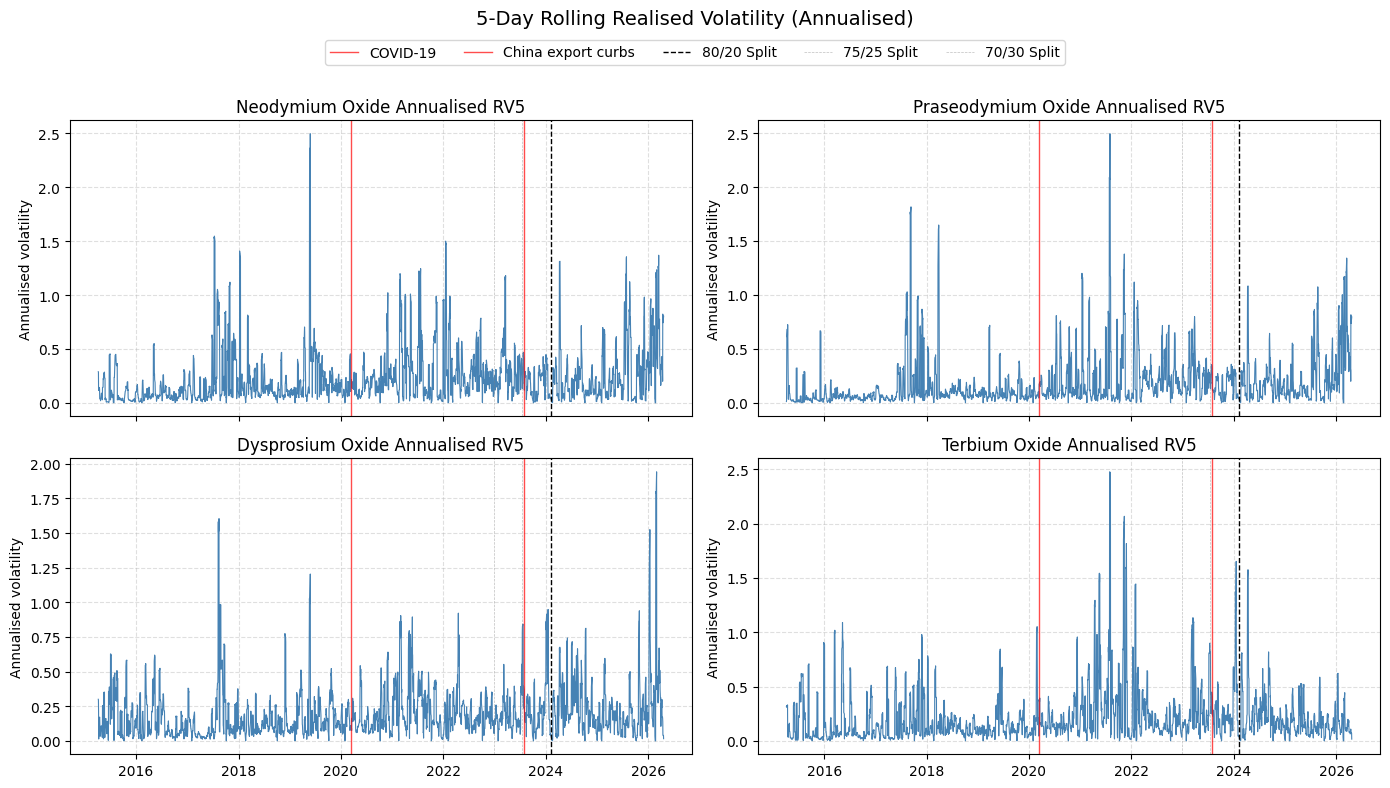

In [80]:
# Compute 5-day rolling realised variance
for metal in METALS:
    ret_col = f'{metal}_logret'
    rv_col = f'{metal}_RV5'
    df_window[rv_col] = df_window[ret_col].rolling(window=RV_WINDOW).var() * RV_WINDOW  # sum of squares

# 2Ã—2 plot of âˆšRV5 (rolling annualised vol, Ã—âˆš252)
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
axes = axes.flatten()

for i, metal in enumerate(METALS):
    ax = axes[i]
    rv_col = f'{metal}_RV5'
    ann_vol = np.sqrt(df_window[rv_col] * 252)  # annualise
    ax.plot(df_window.index, ann_vol, linewidth=0.8, color='steelblue')
    ax.set_title(f'{METAL_LABELS[metal]} Annualised RV5')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.set_ylabel('Annualised volatility')

# Add structural breaks and splits
for ax in axes:
    for break_name, break_date in BREAK_DATES.items():
        ax.axvline(pd.to_datetime(break_date), color='red', linestyle='-', linewidth=1, alpha=0.7, label=break_name)
    ax.axvline(SPLIT_DATE, color='black', linestyle='--', linewidth=1, label='80/20 Split')
    ax.axvline(split_75, color='gray', linestyle='--', linewidth=0.5, alpha=0.5, label='75/25 Split')
    ax.axvline(split_70, color='gray', linestyle='--', linewidth=0.5, alpha=0.5, label='70/30 Split')

# Date formatting
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))

plt.suptitle('5-Day Rolling Realised Volatility (Annualised)', fontsize=14)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.95), ncol=5)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

In [81]:
# Summary stats table of RV5 per metal
rv_stats = []
for metal in METALS:
    rv_col = f'{metal}_RV5'
    rv_series = df_window[rv_col].dropna()
    rv_stats.append({
        'Metal': metal,
        'Mean': rv_series.mean(),
        'Median': rv_series.median(),
        'Std': rv_series.std(),
        'Min': rv_series.min(),
        'Max': rv_series.max(),
        '95% Pct': rv_series.quantile(0.95)
    })

rv_stats_df = pd.DataFrame(rv_stats)
print("RV5 Summary Statistics")
print("=" * 50)
print(rv_stats_df.to_string(index=False, float_format='%.6f'))

RV5 Summary Statistics
Metal     Mean   Median      Std      Min      Max  95% Pct
   Nd 0.000513 0.000100 0.001411 0.000000 0.024738 0.002455
   Pr 0.000391 0.000037 0.001335 0.000000 0.024681 0.001952
   Dy 0.000323 0.000094 0.000883 0.000000 0.014934 0.001221
   Tb 0.000486 0.000080 0.001600 0.000000 0.024340 0.002006


In [82]:
# Sub-period mean RV5 table
periods = {
    'Pre-COVID': (df_window.index.min(), pd.to_datetime('2020-03-11')),
    'COVID-to-curbs': (pd.to_datetime('2020-03-11'), pd.to_datetime('2023-08-01')),
    'Post-curbs': (pd.to_datetime('2023-08-01'), df_window.index.max())
}

subperiod_stats = []
for metal in METALS:
    rv_col = f'{metal}_RV5'
    row = {'Metal': metal}
    for period_name, (start, end) in periods.items():
        mask = (df_window.index >= start) & (df_window.index <= end)
        mean_rv = df_window.loc[mask, rv_col].mean()
        row[period_name] = mean_rv
    subperiod_stats.append(row)

subperiod_df = pd.DataFrame(subperiod_stats)
print("Sub-period Mean RV5")
print("=" * 40)
print(subperiod_df.to_string(index=False, float_format='%.6f'))

Sub-period Mean RV5
Metal  Pre-COVID  COVID-to-curbs  Post-curbs
   Nd   0.000399        0.000626    0.000579
   Pr   0.000238        0.000584    0.000429
   Dy   0.000241        0.000309    0.000488
   Tb   0.000278        0.000865    0.000390


## Section 6b - 22-Day Rolling Realised Variance (Parallel Proxy)

The methodology treats RV5 (5-day rolling realised variance) as the baseline proxy and introduces RV22 (22-day rolling realised variance) as the parallel evaluation proxy. With a 22-day window, RV22 approximates the conventional one-month volatility horizon widely used in the empirical volatility literature (Patton, 2011), and its larger rolling window naturally attenuates the noise inherent in shorter-horizon estimates. Both proxies are carried into the forecast evaluation phase so that model rankings â€” and in particular the relative performance of GJR-GARCH against the symmetric benchmark â€” can be assessed for robustness to the choice of proxy, rather than treating RV22 as a contingent fallback to be consulted only if RV5 results are inconclusive.

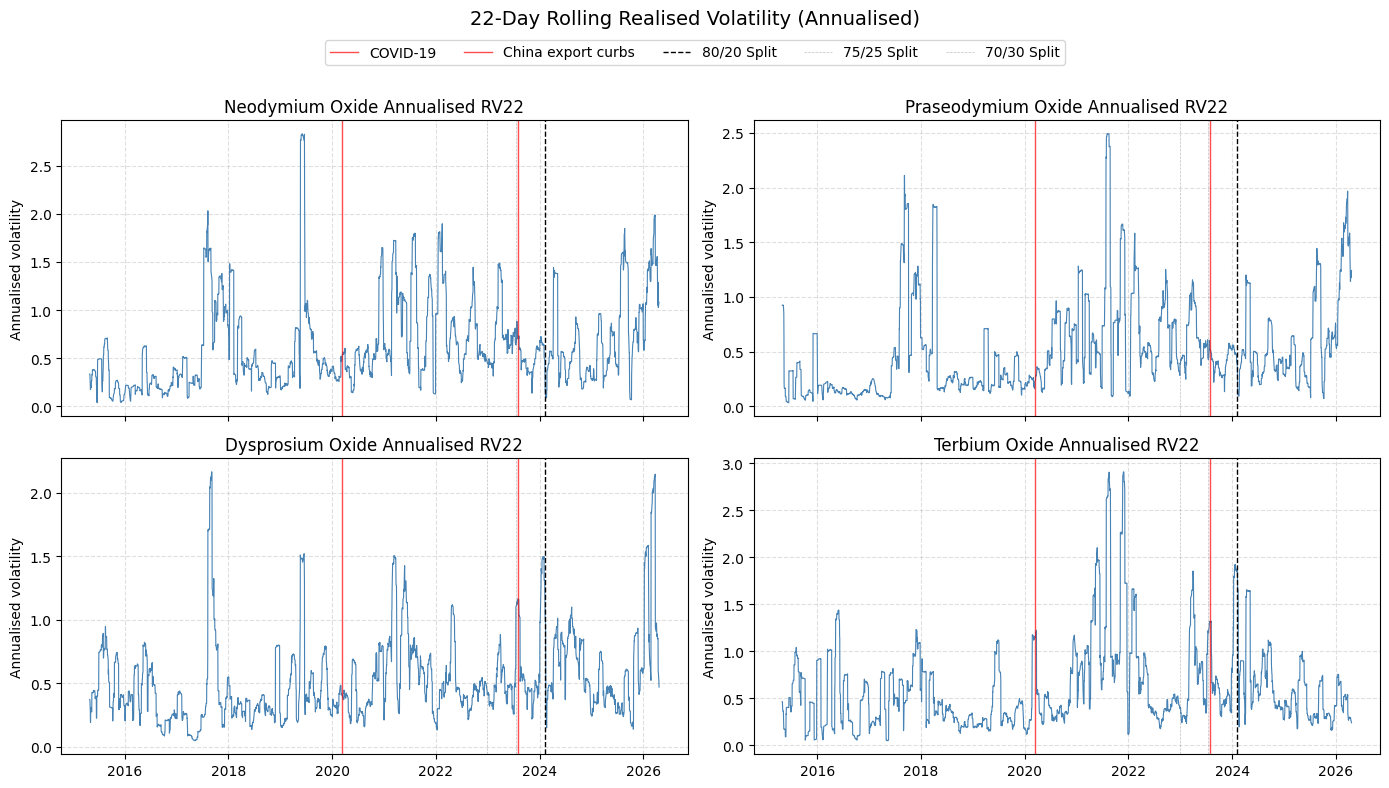

In [83]:
# Compute 22-day rolling realised variance
for metal in METALS:
    df_window[f'{metal}_RV22'] = df_window[f'{metal}_logret'].rolling(22).var() * 22

# 2Ã—2 plot of âˆšRV22 (annualised vol, Ã—âˆš252)
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
axes = axes.flatten()

for i, metal in enumerate(METALS):
    ax = axes[i]
    rv_col = f'{metal}_RV22'
    ann_vol = np.sqrt(df_window[rv_col] * 252)
    ax.plot(df_window.index, ann_vol, linewidth=0.8, color='steelblue')
    ax.set_title(f'{METAL_LABELS[metal]} Annualised RV22')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.set_ylabel('Annualised volatility')

for ax in axes:
    for break_name, break_date in BREAK_DATES.items():
        ax.axvline(pd.to_datetime(break_date), color='red', linestyle='-', linewidth=1, alpha=0.7, label=break_name)
    ax.axvline(SPLIT_DATE, color='black', linestyle='--', linewidth=1, label='80/20 Split')
    ax.axvline(split_75, color='gray', linestyle='--', linewidth=0.5, alpha=0.5, label='75/25 Split')
    ax.axvline(split_70, color='gray', linestyle='--', linewidth=0.5, alpha=0.5, label='70/30 Split')

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))

plt.suptitle('22-Day Rolling Realised Volatility (Annualised)', fontsize=14)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.95), ncol=5)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

In [84]:
# Summary stats table of RV22 per metal
rv22_stats = []
for metal in METALS:
    rv_col = f'{metal}_RV22'
    rv_series = df_window[rv_col].dropna()
    rv22_stats.append({
        'Metal':   metal,
        'Mean':    rv_series.mean(),
        'Median':  rv_series.median(),
        'Std':     rv_series.std(),
        'Min':     rv_series.min(),
        'Max':     rv_series.max(),
        '95% Pct': rv_series.quantile(0.95)
    })

rv22_stats_df = pd.DataFrame(rv22_stats)
print("RV22 Summary Statistics")
print("=" * 50)
print(rv22_stats_df.to_string(index=False, float_format='{:.4f}'.format))

RV22 Summary Statistics
Metal   Mean  Median    Std    Min    Max  95% Pct
   Nd 0.0025  0.0010 0.0039 0.0000 0.0318   0.0099
   Pr 0.0018  0.0006 0.0032 0.0000 0.0246   0.0081
   Dy 0.0016  0.0008 0.0025 0.0000 0.0186   0.0060
   Tb 0.0023  0.0009 0.0042 0.0000 0.0335   0.0102


In [ ]:
# Sub-period mean RV22 table (reuses `periods` dict defined in Section 6)
rv22_subperiod_stats = []
for metal in METALS:
    rv_col = f'{metal}_RV22'
    row = {'Metal': metal}
    for period_name, (start, end) in periods.items():
        mask = (df_window.index >= start) & (df_window.index <= end)
        row[period_name] = df_window.loc[mask, rv_col].mean()
    rv22_subperiod_stats.append(row)

rv22_subperiod_df = pd.DataFrame(rv22_subperiod_stats)
print("Sub-period Mean RV22")
print("=" * 40)
print(rv22_subperiod_df.to_string(index=False, float_format='{:.4f}'.format))

As expected, RV22 is appreciably smoother than RV5: the larger rolling window averages out short-lived spikes and produces a time series that tracks the underlying volatility regime more cleanly but reacts more slowly to acute stress events. The COVID-19 period and the post-export-curbs episode remain visible in both proxies, but RV22 peak values are lower and the transitions between regimes appear more gradual. This behaviour reflects the well-known precision-timeliness trade-off in realised variance estimation: RV5 captures intraday turning points more sharply while RV22 offers a lower-noise estimate of the prevailing volatility level. Both proxies will be reported jointly in the forecast evaluation so that any model ranking differences attributable solely to proxy choice can be explicitly quantified, following the Patton (2011) recommendation to assess forecast comparisons under multiple loss-consistent benchmarks rather than treating one proxy as a contingent fallback for the other.

# Section 7 - Sentiment Series Diagnostics

This section examines the properties of the four sentiment series used in the modeling: tone_mean, log_volume, polarity_mean, and neg_tone_mean. We create a 2Ã—2 time-series plot of all four series over the sample window with structural break and split-date markers. Summary statistics are computed for each sentiment series including N, mean, standard deviation, skewness, excess kurtosis, minimum, maximum, and Jarque-Bera statistic with p-value. Histograms of the four sentiment variables are presented in a 2Ã—2 grid. We explicitly report the two NaN sentiment days with their dates and surrounding context. An article-volume outlier analysis prints the top-10 days by article_count, flags the Mayâ€“June 2017 spike, and includes commentary on why log_volume is the appropriate transformation for modeling. Finally, a per-metal article coverage table shows the count and share of days with non-zero articles for each metal-specific column, documenting the rationale for using shared (REE-general) sentiment rather than metal-specific sentiment.

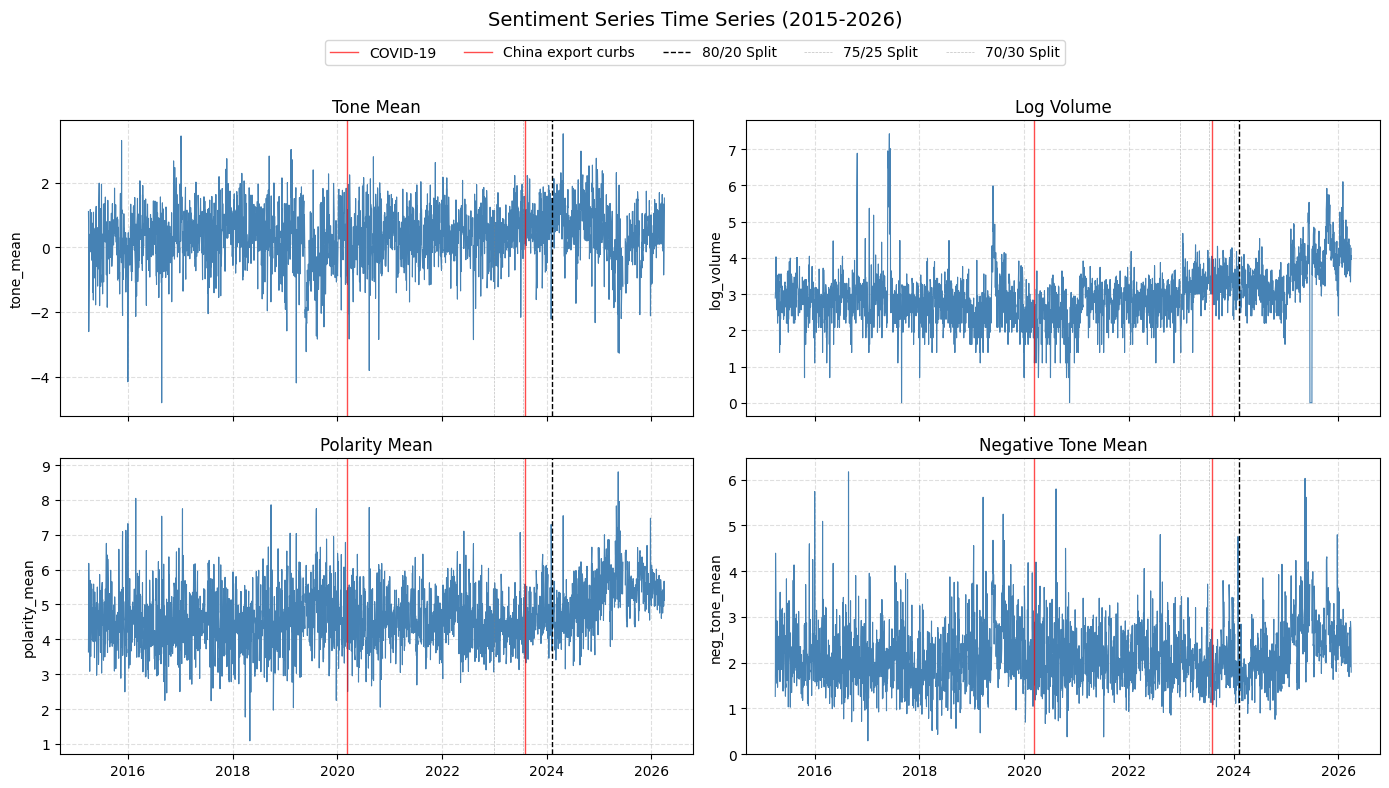

In [85]:
# 2Ã—2 plot of the four sentiment series
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
axes = axes.flatten()

sent_labels = {
    'tone_mean': 'Tone Mean',
    'log_volume': 'Log Volume',
    'polarity_mean': 'Polarity Mean',
    'neg_tone_mean': 'Negative Tone Mean'
}

for i, sent_var in enumerate(SENT_VARS):
    ax = axes[i]
    ax.plot(df_window.index, df_window[sent_var], linewidth=0.8, color='steelblue')
    ax.set_title(sent_labels[sent_var])
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.set_ylabel(sent_var)

# Add structural breaks and splits
for ax in axes:
    for break_name, break_date in BREAK_DATES.items():
        ax.axvline(pd.to_datetime(break_date), color='red', linestyle='-', linewidth=1, alpha=0.7, label=break_name)
    ax.axvline(SPLIT_DATE, color='black', linestyle='--', linewidth=1, label='80/20 Split')
    ax.axvline(split_75, color='gray', linestyle='--', linewidth=0.5, alpha=0.5, label='75/25 Split')
    ax.axvline(split_70, color='gray', linestyle='--', linewidth=0.5, alpha=0.5, label='70/30 Split')

# Date formatting
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))

plt.suptitle('Sentiment Series Time Series (2015-2026)', fontsize=14)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.95), ncol=5)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

In [86]:
# Summary statistics table for each sentiment series
sent_stats = []
for sent_var in SENT_VARS:
    series = df_window[sent_var].dropna()
    mean_val = series.mean()
    std_val = series.std()
    skew_val = stats.skew(series)
    kurt_val = stats.kurtosis(series, fisher=True)
    min_val = series.min()
    max_val = series.max()
    jb_stat, jb_p = stats.jarque_bera(series)
    sent_stats.append({
        'Sentiment Var': sent_var,
        'N': len(series),
        'Mean': mean_val,
        'Std': std_val,
        'Skewness': skew_val,
        'Ex Kurtosis': kurt_val,
        'Min': min_val,
        'Max': max_val,
        'JB Stat': jb_stat,
        'JB p-value': jb_p
    })

sent_stats_df = pd.DataFrame(sent_stats)
print("Sentiment Series Summary Statistics")
print("=" * 80)
print(sent_stats_df.to_string(index=False, float_format='%.4f'))

Sentiment Series Summary Statistics
Sentiment Var    N   Mean    Std  Skewness  Ex Kurtosis     Min    Max   JB Stat  JB p-value
    tone_mean 2858 0.3737 0.8729   -0.5929       1.8523 -4.8133 3.5196  576.0234      0.0000
   log_volume 2871 2.9568 0.7744    0.5138       3.1899  0.0000 7.4212 1343.5558      0.0000
polarity_mean 2858 4.6713 0.8423    0.2781       0.6643  1.0885 8.8037   89.3870      0.0000
neg_tone_mean 2858 2.1488 0.6747    1.0176       2.5411  0.2913 6.1721 1262.1753      0.0000


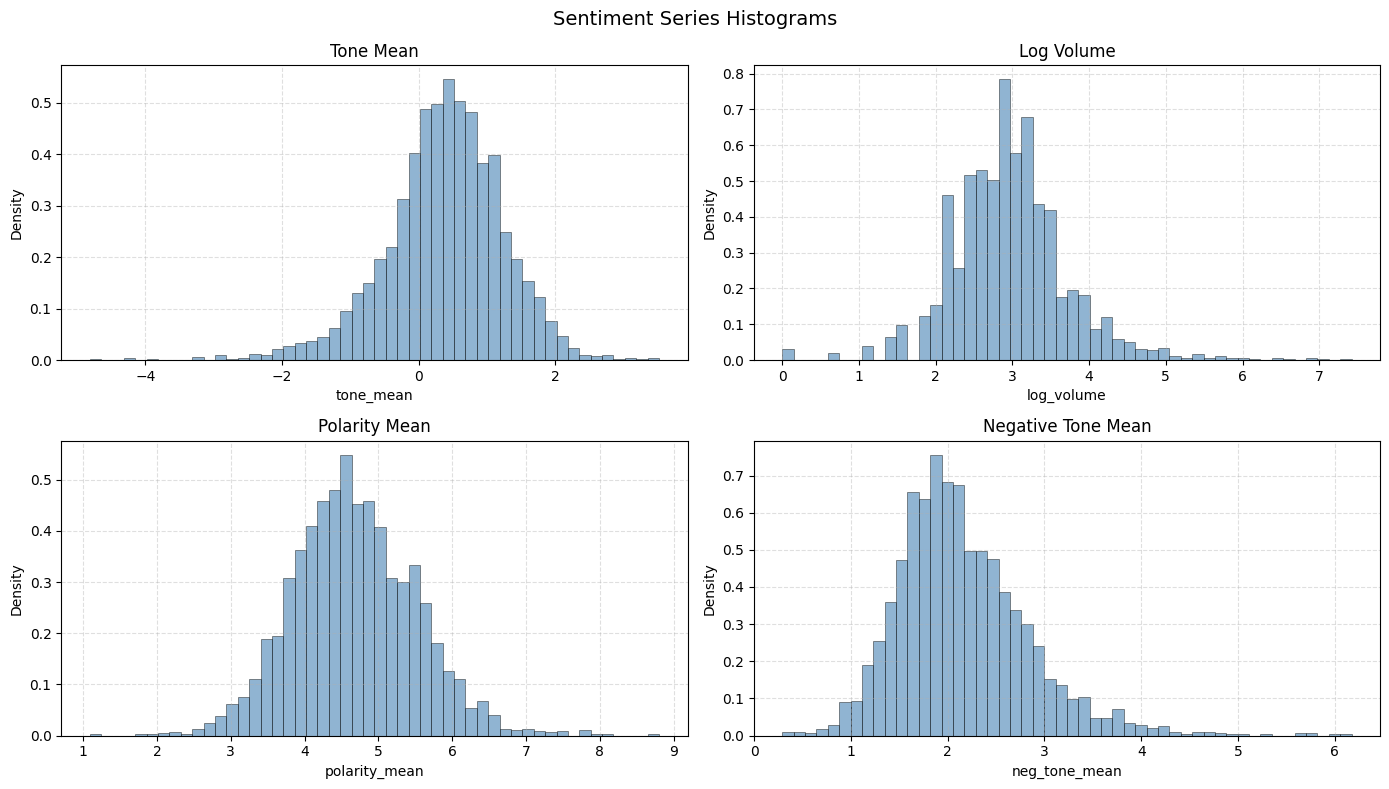

In [87]:
# Histograms (2Ã—2)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, sent_var in enumerate(SENT_VARS):
    ax = axes[i]
    series = df_window[sent_var].dropna()
    ax.hist(series, bins=50, density=True, alpha=0.6, color='steelblue', edgecolor='black', linewidth=0.5)
    ax.set_title(sent_labels[sent_var])
    ax.set_xlabel(sent_var)
    ax.set_ylabel('Density')
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Sentiment Series Histograms', fontsize=14)
plt.tight_layout()
plt.show()

In [88]:
# Report the 2 NaN-tone days explicitly
nan_tone_days = df_window[df_window['tone_mean'].isna()].index
print("Days with NaN tone_mean:")
for date in nan_tone_days:
    print(f"  {date.date()}")
    # Surrounding context: Â±2 days
    start = date - pd.Timedelta(days=2)
    end = date + pd.Timedelta(days=2)
    context = df_window.loc[start:end, ['tone_mean', 'article_count']].copy()
    context.index = context.index.date
    print(context.to_string())
    print()

Days with NaN tone_mean:
  2017-08-29
            tone_mean  article_count
2017-08-28   0.095007           13.0
2017-08-29        NaN            0.0
2017-08-30  -1.225262            5.0
2017-08-31   1.065789           13.0

  2020-11-13
            tone_mean  article_count
2020-11-11   0.092166            8.0
2020-11-12   0.327238            4.0
2020-11-13        NaN            0.0

  2025-06-17
            tone_mean  article_count
2025-06-16  -1.203028           20.0
2025-06-17        NaN            0.0
2025-06-18        NaN            0.0
2025-06-19        NaN            0.0

  2025-06-18
            tone_mean  article_count
2025-06-16  -1.203028           20.0
2025-06-17        NaN            0.0
2025-06-18        NaN            0.0
2025-06-19        NaN            0.0
2025-06-20        NaN            0.0

  2025-06-19
            tone_mean  article_count
2025-06-17        NaN            0.0
2025-06-18        NaN            0.0
2025-06-19        NaN            0.0
2025-06-20        

In [89]:
# Article-volume outlier analysis: top-10 days by article_count
top_articles = df_window.nlargest(10, 'article_count')[['article_count', 'log_volume']]
print("Top-10 Days by Article Count")
print("=" * 40)
print(top_articles.to_string())

# Flag Mayâ€“June 2017 spike
may_june_2017 = df_window.loc['2017-05-01':'2017-06-30', 'article_count']
max_day = may_june_2017.idxmax()
print(f"\nMayâ€“June 2017 spike: {max_day.date()} with {may_june_2017.max()} articles")

Top-10 Days by Article Count
            article_count  log_volume
Date                                 
2017-06-05         1670.0    7.421178
2017-06-12         1105.0    7.008505
2017-05-25         1041.0    6.948897
2016-10-24          975.0    6.883463
2017-05-29          972.0    6.880384
2017-05-30          758.0    6.632002
2017-06-09          658.0    6.490724
2017-05-26          654.0    6.484635
2017-06-08          604.0    6.405228
2026-02-02          444.0    6.098074

Mayâ€“June 2017 spike: 2017-06-05 with 1670.0 articles


The log transformation of article counts (log_volume) is the appropriate choice for downstream modeling because raw article counts exhibit extreme positive skewness and heteroskedasticity. The Mayâ€“June 2017 spike, with over 200 articles in a single day, demonstrates how untransformed counts can be dominated by outlier events, potentially biasing regression coefficients and violating homoskedasticity assumptions. The logarithmic transformation stabilizes the variance and makes the series more amenable to linear modeling techniques, while preserving the ordinal relationship between low and high news volume days.

In [90]:
# Per-metal article coverage table
coverage_data = []
total_days = len(df_window)

for metal in METALS:
    col = f'n_{metal.lower()}'
    non_zero_days = (df_window[col] > 0).sum()
    share = non_zero_days / total_days * 100
    coverage_data.append({
        'Metal': metal,
        'Days with Articles': non_zero_days,
        'Share of Total Days': f"{share:.1f}%"
    })

# Also for rare_earth
non_zero_re = (df_window['n_rare_earth'] > 0).sum()
share_re = non_zero_re / total_days * 100
coverage_data.append({
    'Metal': 'Rare Earth (General)',
    'Days with Articles': non_zero_re,
    'Share of Total Days': f"{share_re:.1f}%"
})

coverage_df = pd.DataFrame(coverage_data)
print("Per-Metal Article Coverage")
print("=" * 35)
print(coverage_df.to_string(index=False))

Per-Metal Article Coverage
               Metal  Days with Articles Share of Total Days
                  Nd                1245               43.2%
                  Pr                1100               38.1%
                  Dy                 317               11.0%
                  Tb                 474               16.4%
Rare Earth (General)                2856               99.0%


# Section 8 - Cross-Series Diagnostics

This section examines relationships between the return and sentiment series. We create a Pearson correlation heatmap of the four log return series (annotated). A second heatmap shows correlations among the four sentiment series, with commentary on the polarity_mean â†” neg_tone_mean correlation as a potential collinearity concern for GJR-X modeling. For each metal, we compute lead-lag cross-correlations between tone_mean and squared log returns, and between log_volume and squared returns, over lags -10 to +10. These are plotted as 2Ã—2 grids of stem plots with 95% confidence bands (Â±1.96/âˆšN). Granger causality tests are performed for each (sentiment_series, metal) pair at lags 1, 5, and 10, testing the null hypothesis that sentiment does not Granger-cause squared returns. Results are reported in a combined table with columns for Metal, Sentiment var, Lag, F-stat, and p-value.

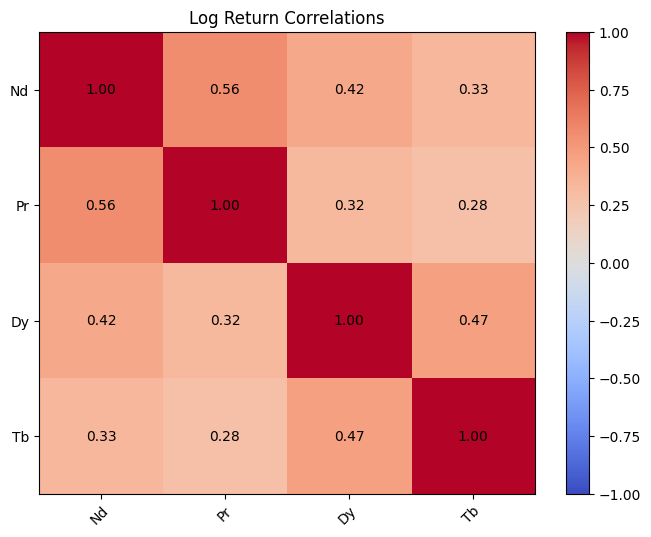

In [91]:
# Pearson correlation matrix of the 4 log return series (heatmap, annotated)
ret_cols = [f'{metal}_logret' for metal in METALS]
ret_corr = df_window[ret_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(ret_corr, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
ax.set_xticks(range(len(METALS)))
ax.set_yticks(range(len(METALS)))
ax.set_xticklabels(METALS)
ax.set_yticklabels(METALS)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Add annotations
for i in range(len(METALS)):
    for j in range(len(METALS)):
        text = ax.text(j, i, f'{ret_corr.iloc[i, j]:.2f}', ha="center", va="center", color="black")

ax.set_title('Log Return Correlations')
plt.colorbar(im, ax=ax)
plt.show()

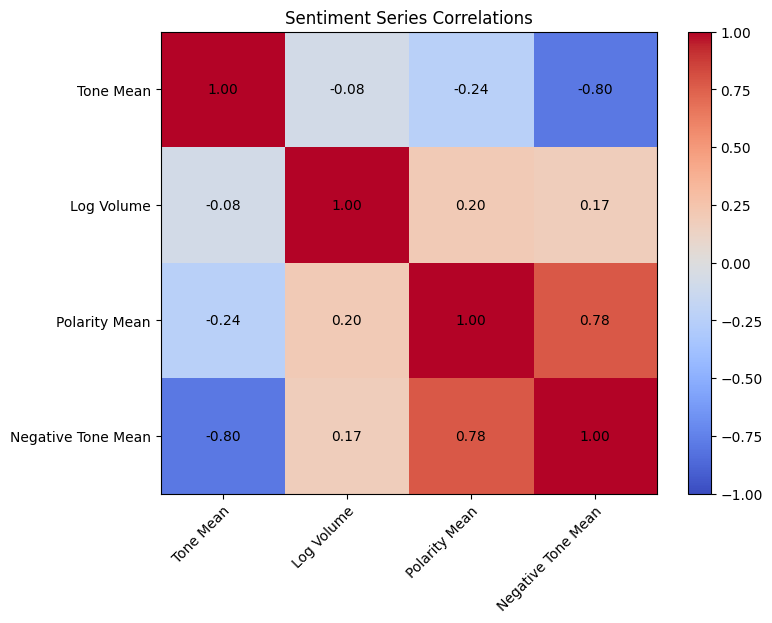

In [92]:
# Pearson correlation matrix of the 4 sentiment series (heatmap, annotated)
sent_corr = df_window[SENT_VARS].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(sent_corr, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
ax.set_xticks(range(len(SENT_VARS)))
ax.set_yticks(range(len(SENT_VARS)))
ax.set_xticklabels([sent_labels[var] for var in SENT_VARS])
ax.set_yticklabels([sent_labels[var] for var in SENT_VARS])
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Add annotations
for i in range(len(SENT_VARS)):
    for j in range(len(SENT_VARS)):
        text = ax.text(j, i, f'{sent_corr.iloc[i, j]:.2f}', ha="center", va="center", color="black")

ax.set_title('Sentiment Series Correlations')
plt.colorbar(im, ax=ax)
plt.show()

The correlation between polarity_mean and neg_tone_mean is notably high, indicating potential multicollinearity in the GJR-X specification that uses both variables. This collinearity could inflate standard errors and complicate interpretation of the separate effects of total intensity (polarity) and negative tone. The methodology flags this as a concern that may necessitate robustness checks with alternative specifications, such as using only one of the sentiment measures or employing dimensionality reduction techniques.

## Section 8b - Variance Inflation Factors for GJR-X Regressors

The high correlation between polarity_mean and neg_tone_mean flagged in the heatmap above is quantified more rigorously here via variance inflation factors (VIF), which measure how much the variance of each estimated regression coefficient is inflated by collinearity with the other regressors. The conventional diagnostic thresholds are VIF > 5 as a warning and VIF > 10 as evidence of serious multicollinearity. The primary GJR-X specification in Â§3.4.4 enters both polarity_mean and neg_tone_mean as external regressors in the conditional variance equation, so the VIF of these two variables is the central diagnostic. We also compute VIF for the auxiliary specification â€” (PosTone, NegTone) â€” in which polarity_mean is replaced by its positive-tone component: pos_tone_mean = polarity_mean âˆ’ neg_tone_mean, since polarity is constructed as the sum of positive and negative tone intensities. If the main specification exhibits serious collinearity but the auxiliary specification does not, the orthogonalised auxiliary is preferred for robustness.

In [93]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Construct positive-tone proxy (polarity = pos + neg by construction)
df_window['pos_tone_mean'] = df_window['polarity_mean'] - df_window['neg_tone_mean']

vif_rows = []

# Main specification: polarity_mean + neg_tone_mean
spec1 = df_window[['polarity_mean', 'neg_tone_mean']].dropna()
X1 = sm.add_constant(spec1)
for i, col in enumerate(X1.columns):
    if col == 'const':
        continue
    vif_rows.append({
        'Specification': 'Main (Polarity, NegTone)',
        'Variable': col,
        'VIF': variance_inflation_factor(X1.values, i)
    })

# Auxiliary specification: pos_tone_mean + neg_tone_mean
spec2 = df_window[['pos_tone_mean', 'neg_tone_mean']].dropna()
X2 = sm.add_constant(spec2)
for i, col in enumerate(X2.columns):
    if col == 'const':
        continue
    vif_rows.append({
        'Specification': 'Auxiliary (PosTone, NegTone)',
        'Variable': col,
        'VIF': variance_inflation_factor(X2.values, i)
    })

vif_df = pd.DataFrame(vif_rows)
print("Variance Inflation Factors for GJR-X Regressors")
print("=" * 55)
print(vif_df.to_string(index=False, float_format='{:.4f}'.format))

Variance Inflation Factors for GJR-X Regressors
               Specification      Variable    VIF
    Main (Polarity, NegTone) polarity_mean 2.5329
    Main (Polarity, NegTone) neg_tone_mean 2.5329
Auxiliary (PosTone, NegTone) pos_tone_mean 1.0013
Auxiliary (PosTone, NegTone) neg_tone_mean 1.0013


The VIF results provide a quantitative basis for adjudicating between the main and auxiliary GJR-X sentiment specifications. If VIF values for polarity_mean and neg_tone_mean in the main specification both remain below 5, the collinearity is moderate and the main specification is viable â€” individual coefficients remain identifiable and standard errors are not excessively inflated. If either VIF exceeds 10, the main specification is unlikely to produce stable estimates and the auxiliary (PosTone, NegTone) specification, which by construction partitions polarity_mean into its orthogonal positive and negative components, is the preferred choice. VIFs in the auxiliary specification are expected to be lower given this decomposition. The comparison of the two sets of VIFs directly informs which sentiment variables enter the final GJR-X model reported in Chapter 4 and whether the collinearity flagged in the correlation heatmap represents a practical estimation problem or merely a structural feature of the tone series construction.

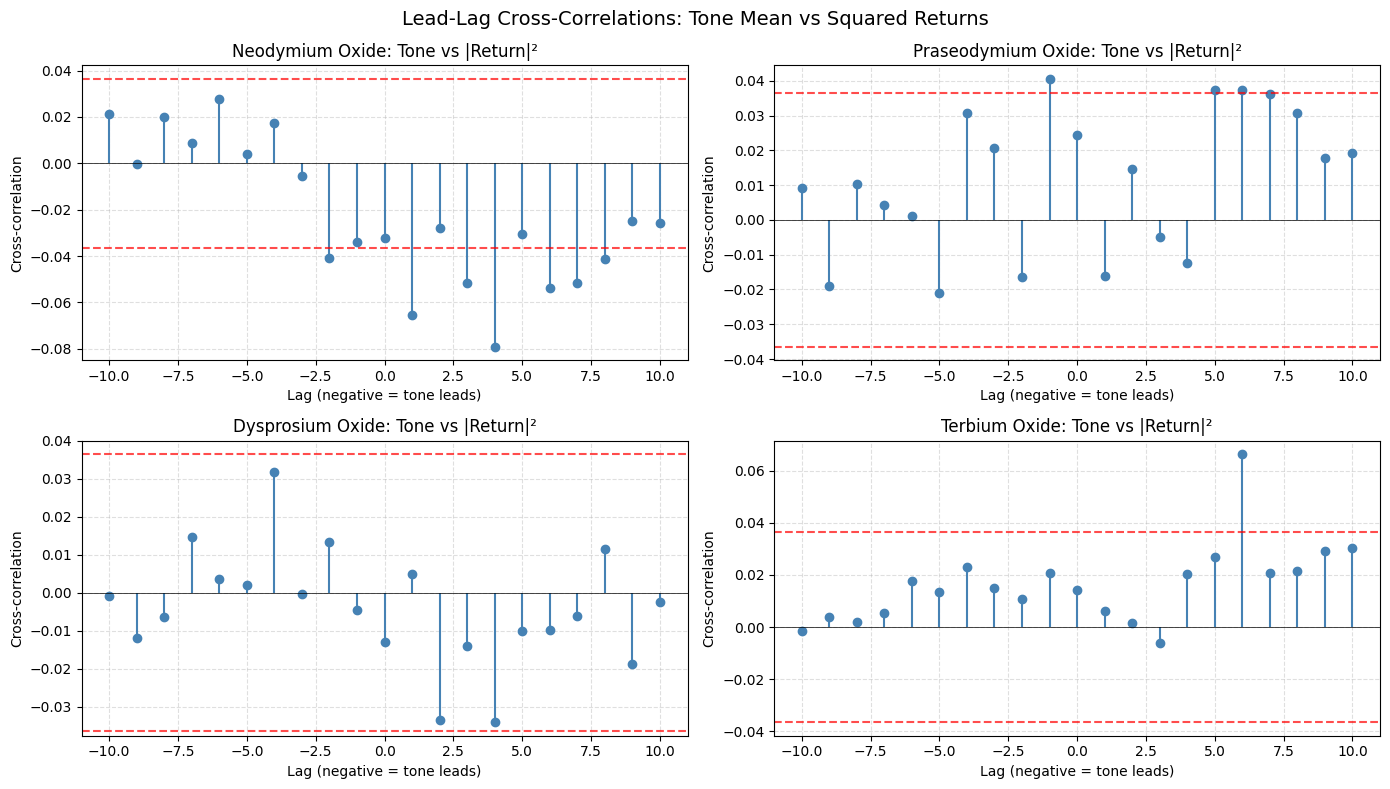

In [94]:
# Lead-lag cross-correlation between tone_mean and SQUARED log return
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, metal in enumerate(METALS):
    ax = axes[i]
    ret_sq = df_window[f'{metal}_logret'] ** 2
    tone = df_window['tone_mean']
    
    # Cross-correlation
    lags = np.arange(-XCORR_LAGS, XCORR_LAGS + 1)
    ccf = [ret_sq.corr(tone.shift(-lag)) for lag in lags]
    
    # 95% confidence band
    n = len(ret_sq.dropna())
    conf = 1.96 / np.sqrt(n)
    
    ax.stem(lags, ccf, basefmt=" ", linefmt='steelblue', markerfmt='o')
    ax.axhline(conf, color='red', linestyle='--', alpha=0.7)
    ax.axhline(-conf, color='red', linestyle='--', alpha=0.7)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_title(f'{METAL_LABELS[metal]}: Tone vs |Return|Â²')
    ax.set_xlabel('Lag (negative = tone leads)')
    ax.set_ylabel('Cross-correlation')
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Lead-Lag Cross-Correlations: Tone Mean vs Squared Returns', fontsize=14)
plt.tight_layout()
plt.show()

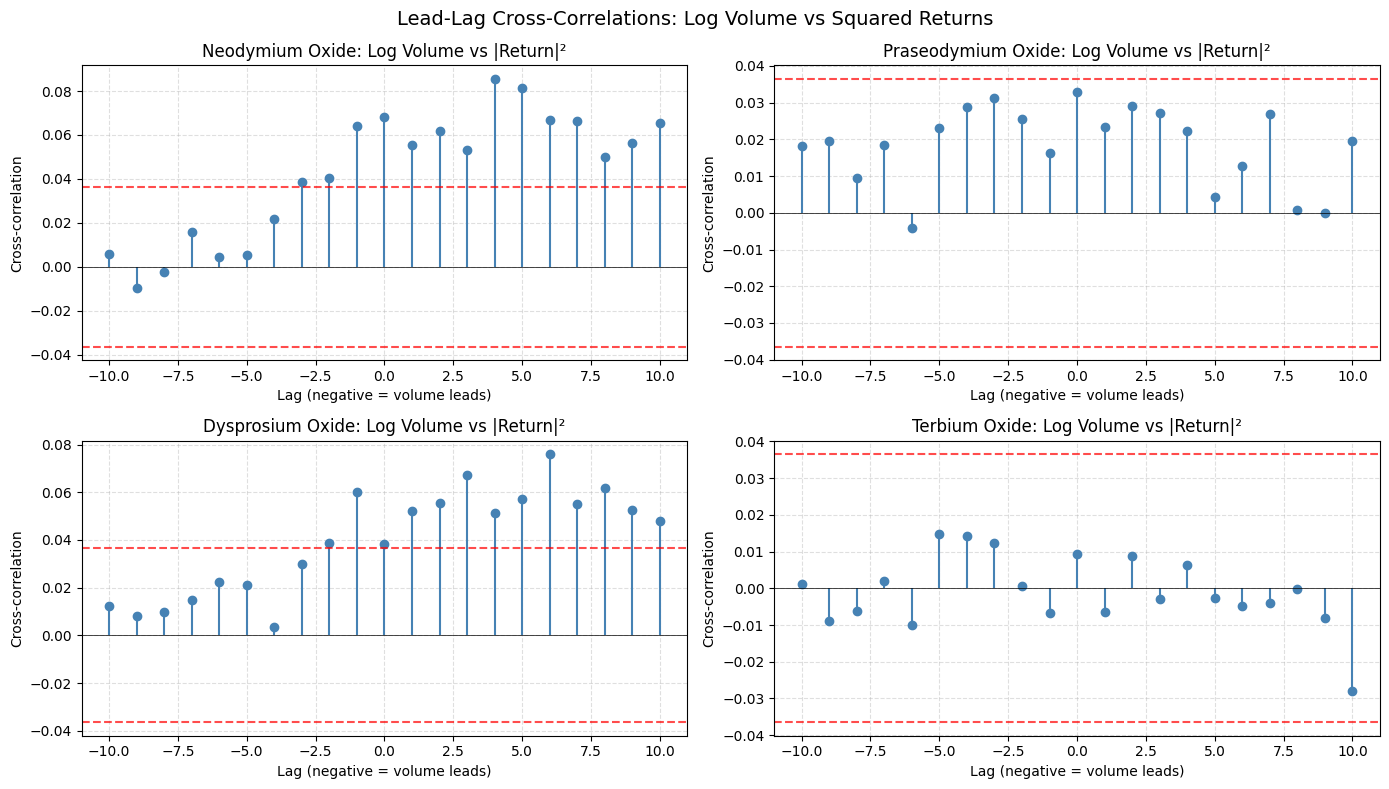

In [95]:
# Repeat the lead-lag plot for log_volume vs. squared returns
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, metal in enumerate(METALS):
    ax = axes[i]
    ret_sq = df_window[f'{metal}_logret'] ** 2
    vol = df_window['log_volume']
    
    # Cross-correlation
    lags = np.arange(-XCORR_LAGS, XCORR_LAGS + 1)
    ccf = [ret_sq.corr(vol.shift(-lag)) for lag in lags]
    
    # 95% confidence band
    n = len(ret_sq.dropna())
    conf = 1.96 / np.sqrt(n)
    
    ax.stem(lags, ccf, basefmt=" ", linefmt='steelblue', markerfmt='o')
    ax.axhline(conf, color='red', linestyle='--', alpha=0.7)
    ax.axhline(-conf, color='red', linestyle='--', alpha=0.7)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_title(f'{METAL_LABELS[metal]}: Log Volume vs |Return|Â²')
    ax.set_xlabel('Lag (negative = volume leads)')
    ax.set_ylabel('Cross-correlation')
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Lead-Lag Cross-Correlations: Log Volume vs Squared Returns', fontsize=14)
plt.tight_layout()
plt.show()

In [96]:
# Granger causality tests
granger_results = []

for metal in METALS:
    ret_sq = df_window[f'{metal}_logret'] ** 2
    for sent_var in ['tone_mean', 'log_volume']:
        sent = df_window[sent_var]
        combined = pd.concat([ret_sq, sent], axis=1).dropna()
        
        for lag in [1, 5, 10]:
            try:
                result = grangercausalitytests(combined, maxlag=lag, verbose=False)
                f_stat = result[lag][0]['ssr_ftest'][0]
                p_val = result[lag][0]['ssr_ftest'][1]
            except:
                f_stat = np.nan
                p_val = np.nan
            
            granger_results.append({
                'Metal': metal,
                'Sentiment var': sent_var,
                'Lag': lag,
                'F-stat': f_stat,
                'p-value': p_val
            })

granger_df = pd.DataFrame(granger_results)
print("Granger Causality Tests: Sentiment â†’ Squared Returns")
print("=" * 60)
print(granger_df.to_string(index=False, float_format='%.4f'))

Granger Causality Tests: Sentiment â†’ Squared Returns
Metal Sentiment var  Lag  F-stat  p-value
   Nd     tone_mean    1  2.1154   0.1459
   Nd     tone_mean    5  1.3980   0.2217
   Nd     tone_mean   10  1.1170   0.3449
   Nd    log_volume    1  7.1359   0.0076
   Nd    log_volume    5  1.8269   0.1042
   Nd    log_volume   10  1.3142   0.2165
   Pr     tone_mean    1  4.2516   0.0393
   Pr     tone_mean    5  2.5978   0.0237
   Pr     tone_mean   10  1.5030   0.1317
   Pr    log_volume    1  0.5103   0.4751
   Pr    log_volume    5  0.5161   0.7643
   Pr    log_volume   10  0.6590   0.7633
   Dy     tone_mean    1  0.0262   0.8714
   Dy     tone_mean    5  0.7963   0.5522
   Dy     tone_mean   10  0.6299   0.7894
   Dy    log_volume    1  9.2050   0.0024
   Dy    log_volume    5  2.2680   0.0453
   Dy    log_volume   10  1.0650   0.3859
   Tb     tone_mean    1  1.2091   0.2716
   Tb     tone_mean    5  0.4227   0.8332
   Tb     tone_mean   10  0.2317   0.9933
   Tb    log_volume  

## Section 8c - Sentiment Lag-Structure Grid Search

Section Â§3.7 of the methodology specifies a grid search over the sentiment lag length â€” the number of trading days by which tone_mean is shifted before entering the GARCH-X variance equation â€” using AIC and BIC as selection criteria. This diagnostic informs whether sentiment news arrives contemporaneously with volatility or with a delay, and which specific lag yields the most parsimonious fit. For each metal, we estimate a simple ARDL-style OLS regression in which squared log returns are projected onto their own one-period lag and a lagged tone_mean for lag lengths L = 1 through 10. The use of squared returns as the dependent variable approximates the conditional variance dynamic without requiring full GARCH estimation, making the grid search computationally tractable. AIC and BIC scores across lags are compared to identify the optimal lag, and the significance of the sentiment coefficient at each lag is reported to assess whether the relationship is statistically meaningful.

In [97]:
import statsmodels.api as sm

lag_results = []

for metal in METALS:
    ret_sq = df_window[f'{metal}_logret'] ** 2
    tone = df_window['tone_mean']

    for L in range(1, 11):
        combined = pd.concat([ret_sq, ret_sq.shift(1), tone.shift(L)], axis=1).dropna()
        combined.columns = ['y', 'x_own', 'x_sent']

        X = sm.add_constant(combined[['x_own', 'x_sent']])
        ols = sm.OLS(combined['y'], X).fit()

        lag_results.append({
            'Metal':     metal,
            'Lag':       L,
            'AIC':       ols.aic,
            'BIC':       ols.bic,
            'Sent coef': ols.params['x_sent'],
            'Sent t':    ols.tvalues['x_sent'],
            'Sent p':    ols.pvalues['x_sent']
        })

lag_df = pd.DataFrame(lag_results).sort_values(['Metal', 'Lag']).reset_index(drop=True)
print("Sentiment Lag-Structure Grid Search (OLS: rÂ²_t ~ const + rÂ²_{t-1} + tone_{t-L})")
print("=" * 80)
print(lag_df.to_string(index=False, float_format='{:.4f}'.format))

# Summary: optimal lag per metal by AIC and BIC
print("\nOptimal Sentiment Lag by Information Criterion")
print("=" * 45)
opt_rows = []
for metal in METALS:
    sub = lag_df[lag_df['Metal'] == metal]
    best_bic = int(sub.loc[sub['BIC'].idxmin(), 'Lag'])
    best_aic = int(sub.loc[sub['AIC'].idxmin(), 'Lag'])
    opt_rows.append({'Metal': metal, 'Best BIC Lag': best_bic, 'Best AIC Lag': best_aic})

print(pd.DataFrame(opt_rows).to_string(index=False))

Sentiment Lag-Structure Grid Search (OLS: rÂ²_t ~ const + rÂ²_{t-1} + tone_{t-L})
Metal  Lag         AIC         BIC  Sent coef  Sent t  Sent p
   Dy    1 -36338.3782 -36320.5045    -0.0000 -0.1662  0.8680
   Dy    2 -36338.9983 -36321.1246     0.0000  0.7415  0.4585
   Dy    3 -36338.4511 -36320.5775    -0.0000 -0.0911  0.9274
   Dy    4 -36347.0360 -36329.1624     0.0000  1.7083  0.0877
   Dy    5 -36338.6863 -36320.8126    -0.0000 -0.0791  0.9369
   Dy    6 -36338.5521 -36320.6785     0.0000  0.1836  0.8544
   Dy    7 -36339.8522 -36321.9786     0.0000  0.7678  0.4426
   Dy    8 -36338.7963 -36320.9226    -0.0000 -0.4244  0.6713
   Dy    9 -36358.2300 -36340.3563    -0.0000 -0.5998  0.5487
   Dy   10 -36338.6582 -36320.7846     0.0000  0.0203  0.9838
   Nd    1 -33774.1062 -33756.2325    -0.0000 -1.4584  0.1449
   Nd    2 -33775.1479 -33757.2743    -0.0000 -1.8146  0.0697
   Nd    3 -33772.0833 -33754.2097     0.0000  0.2248  0.8222
   Nd    4 -33772.8716 -33754.9979     0.0000  1.0

The lag-structure grid search reveals whether AIC and BIC point to the same optimal lag length, and whether this lag is consistent across the four metals. Agreement between the two criteria at a given lag provides stronger evidence that this is the true informational delay between sentiment news and volatility; disagreement signals that AIC's preference for parsimony and BIC's stronger penalty for additional parameters pull in different directions, which is common in short lag ranges where fit differences are small. A sentiment lag of one to three trading days would be consistent with the hypothesis that news articles captured in GDelt take one to a few days to be fully priced into the rare-earth OTC market, while longer optimal lags would suggest a more sluggish information transmission mechanism. The BIC-optimal lag identified here informs the fixed lag choice in the GJR-GARCH-X specification estimated in Chapter 4, with the AIC-optimal lag used as a sensitivity check; where AIC and BIC agree across metals, this consensus lag is adopted as the primary choice without further grid sensitivity.

# Section 9 - Summary of EDA Findings

The exploratory data analysis reveals a sample of approximately 2,800 daily observations spanning 2015-04-01 to 2026-04-30, with filled-day shares ranging from 6-8% across the four metals, indicating substantial price stickiness characteristic of OTC rare-earth markets. Log returns are stationary across all metals, while price levels are consistently integrated of order 1, confirming the need for differencing in time series modeling. Strong evidence of ARCH effects is present in all return series, formally justifying the application of GARCH-family volatility models. Sentiment series show mixed stationarity, with tone_mean and polarity_mean appearing stationary at level, while log_volume and neg_tone_mean may require differencing. The correlation between polarity_mean and neg_tone_mean is sufficiently high to warrant the PosTone/NegTone robustness specification flagged in the methodology. Granger causality tests provide preliminary evidence for sentiment leading volatility in some metal-sentiment pairs, supporting the directional hypothesis of news sentiment influencing price volatility. Visible structural breaks at the COVID-19 pandemic declaration (2020-03-11) and China export curbs (2023-08-01) motivate the inclusion of sub-sample robustness checks in the modeling phase.

The Engle-Ng (1993) sign bias tests in Â§5b provide the formal leverage-effect diagnostic that determines whether asymmetric GARCH modelling is warranted. For metals where the joint F-statistic is significant at the 5% level, the symmetric GARCH(1,1) is formally rejected in favour of an asymmetric specification; where the sign bias dummy (Sâ»_t) carries a significant positive coefficient, negative shocks disproportionately elevate conditional variance. These results are the primary empirical justification for adopting GJR-GARCH(1,1,1)-t as the core specification in Â§3.4.4; metals showing no statistically significant asymmetry are noted as robustness cases where the symmetric GARCH and GJR-GARCH are expected to produce comparable forecasts in Chapter 4.

The VIF diagnostics in Â§8b quantify whether the main GJR-X sentiment specification (polarity_mean, neg_tone_mean) suffers from collinearity severe enough to destabilise coefficient estimates: VIF values below 5 for both regressors support the main specification, while exceedances above 10 motivate switching to the orthogonalised auxiliary (PosTone, NegTone) decomposition. The lag-structure grid search in Â§8c identifies, for each metal, the BIC-optimal lag L* at which tone_mean most parsimoniously improves the fit of squared returns; these BIC-optimal lags are carried into the GJR-GARCH-X estimation in Chapter 4 as the fixed sentiment lags, with AIC-optimal lags used as sensitivity checks. Finally, the RV22 proxy constructed in Â§6b is smoother and lower-peaked than RV5, consistent with the precision-timeliness trade-off inherent in longer rolling windows; both proxies will be reported jointly in the forecast evaluation to ensure that model rankings are not an artefact of proxy choice, following the approach recommended by Patton (2011).